### 1. CARREGAMENTO DOS DATASETS

Nesta etapa, realiza-se o download e a consolidação dos dados provenientes das simulações numéricas (Abaqus) que compõem o Design of Experiments (DoE) para o treinamento das redes neurais MLP.

In [16]:
import pandas as pd
import numpy as np
import os
import gdown

# ===================================================================
# 1. PRÉ-PROCESSAMENTO: CARREGAMENTO DOS DADOS DE SIMULAÇÃO
# ===================================================================

# URL pública do repositório contendo os resultados numéricos
url_pasta_drive = 'https://drive.google.com/drive/folders/1rVx_WWO1ZZl5QJVsmDynqaQaiYogo1Cb?usp=sharing'
dir_dados = '/content/Data_Abaqus'

print("Verificando a existência dos dados no ambiente local...")
# Realiza o download apenas se o diretório não existir
if not os.path.exists(dir_dados):
    gdown.download_folder(url_pasta_drive, output=dir_dados, quiet=False, use_cookies=False)

# Definição dos arquivos CSV a serem consolidados (resultados das análises paramétricas)
arquivos_csv = [
    'Dataset_DoE1000_Final_Extraido.csv',
    'Dataset_Fronteira_Extraido_COMPLETO.csv',
   # 'DoE_Fronteira_Abaqus_45a80_300.csv',
]

dfs = []
for arquivo in arquivos_csv:
    caminho_completo = f"{dir_dados}/{arquivo}"
    try:
        df_temp = pd.read_csv(caminho_completo)
        dfs.append(df_temp)
        print(f"[OK] Dataset carregado: {arquivo} ({len(df_temp)} instâncias)")
    except FileNotFoundError:
        print(f"[AVISO] Arquivo não encontrado no repositório: {caminho_completo}")

if dfs:
    # Agrega todos os conjuntos de dados em um único DataFrame Pandas
    df = pd.concat(dfs, ignore_index=True)

    # Remove potenciais duplicatas decorrentes da sobreposição de varreduras no DoE
    df = df.drop_duplicates(subset=['Massa_TNT_kg', 'Espessura_mm', 'Distancia_Z_mm'])

    print("\n" + "="*40)
    print("ESTATÍSTICAS GERAIS DO CONJUNTO DE DADOS")
    print("="*40)
    print(f"Total de simulações únicas: {len(df)}")
    print(f"Instâncias sem ruptura estrutural (Status 0): {len(df[df['Status_Ruptura'] == 0])}")
    print(f"Instâncias com ruptura estrutural (Status 1): {len(df[df['Status_Ruptura'] == 1])}")

    # Exibição das primeiras amostras para validação da estrutura de dados
    display(df.head())
else:
    print("Erro: Nenhum dataset válido foi carregado.")


Verificando a existência dos dados no ambiente local...
[OK] Dataset carregado: Dataset_DoE1000_Final_Extraido.csv (1000 instâncias)
[OK] Dataset carregado: Dataset_Fronteira_Extraido_COMPLETO.csv (500 instâncias)

ESTATÍSTICAS GERAIS DO CONJUNTO DE DADOS
Total de simulações únicas: 1500
Instâncias sem ruptura estrutural (Status 0): 1173
Instâncias com ruptura estrutural (Status 1): 327


,Arquivo_Origem,Massa_TNT_kg,Espessura_mm,Distancia_Z_mm,Max_Desloc_U_m,Max_PEEQ,Max_Tensao_VonMises_Pa,Status_Ruptura,Max_Tensao_Principal_Pa,Desloc_Eixo_Z_m
0,DoE_A36_001_M4985g_Z1081mm_e5p72mm,4.985,5.72,1081.0,0.025260,0.118868,642843584.0,0,212497168.0,0.025246
1,DoE_A36_002_M153g_Z1966mm_e6p6mm,0.153,6.60,1966.0,0.000060,0.000000,8917738.0,0,9241034.0,0.000060
2,DoE_A36_003_M313g_Z315mm_e5p44mm,0.313,5.44,315.0,0.016253,0.057588,641715456.0,0,739334528.0,0.016251
3,DoE_A36_004_M3407g_Z2978mm_e4p28mm,3.407,4.28,2978.0,0.001988,0.023527,227209056.0,0,42074772.0,0.001988
4,DoE_A36_005_M4904g_Z1925mm_e4p72mm,4.904,4.72,1925.0,0.014639,0.069855,229259696.0,0,187730336.0,0.014637


### 1.5. TRATAMENTO DE DADOS (Pré-filtragem Físico-Mecânica)

Esta etapa garante que os dados utilizados no treinamento sejam estritamente limitados ao envelope de validade física das simulações computacionais. Filtram-se anomalias numéricas ou configurações fora do escopo validado (e.g., limitações do modelo de detonação *Air Blast* do método CONWEP/Abaqus).

In [47]:
# ===================================================================
# TRATAMENTO DE DADOS: APLICAÇÃO DE RESTRIÇÕES DE VALIDADE FÍSICA
# ===================================================================

# 1. Preservação do conjunto bruto original
df_bruto = df.copy()

# 2. Definição das restrições fundamentadas no modelo numérico
# LIMITE_MIN_Z_MM: A formulação CONWEP perde validade no campo próximo a detonação (near-field).
LIMITE_MIN_Z_MM = 100.0
# LIMITE_MAX_ESP_MM: Relação espessura/comprimento para o elemento de casca (Shell S4R).
LIMITE_MAX_ESP_MM = 8.1

df_filtrado = df_bruto[
    (df_bruto['Distancia_Z_mm'] >= LIMITE_MIN_Z_MM) &
    (df_bruto['Espessura_mm'] <= LIMITE_MAX_ESP_MM)
]

# Atualização da base de trabalho para modelagem preditiva
df = df_filtrado.copy()

# 3. Estatísticas da filtragem e domínio amostral
casos_descartados = len(df_bruto) - len(df)

print("====================================================================")
print("              RELATÓRIO DE HIGIENIZAÇÃO DE DADOS                    ")
print("====================================================================")
print(f"Tamanho amostral original: {len(df_bruto)}")
print(f"Amostras removidas (violação das premissas numéricas): {casos_descartados}")
print(f"Amostras elegíveis para treinamento (MLP): {len(df)}")
print("\n[DOMÍNIO DE PARÂMETROS DO TREINAMENTO]")
print(f"Espessura (mm): {df['Espessura_mm'].min():.1f} a {df['Espessura_mm'].max():.1f}")
print(f"Massa TNT (kg): {df['Massa_TNT_kg'].min():.2f} a {df['Massa_TNT_kg'].max():.2f}")
print(f"Distância Z (mm): {df['Distancia_Z_mm'].min():.1f} a {df['Distancia_Z_mm'].max():.1f}")
print("====================================================================")


              RELATÓRIO DE HIGIENIZAÇÃO DE DADOS                    
Tamanho amostral original: 1469
Amostras removidas (violação das premissas numéricas): 0
Amostras elegíveis para treinamento (MLP): 1469

[DOMÍNIO DE PARÂMETROS DO TREINAMENTO]
Espessura (mm): 1.0 a 8.0
Massa TNT (kg): 0.10 a 5.00
Distância Z (mm): 192.0 a 2998.0



Amostras destinadas à regressão de deslocamento (Íntegras): 1173 de 1500

Iniciando o treinamento do modelo classificador de falhas...
Iniciando o treinamento do modelo de regressão de deslocamento contínuo...
Processos de convergência concluídos.



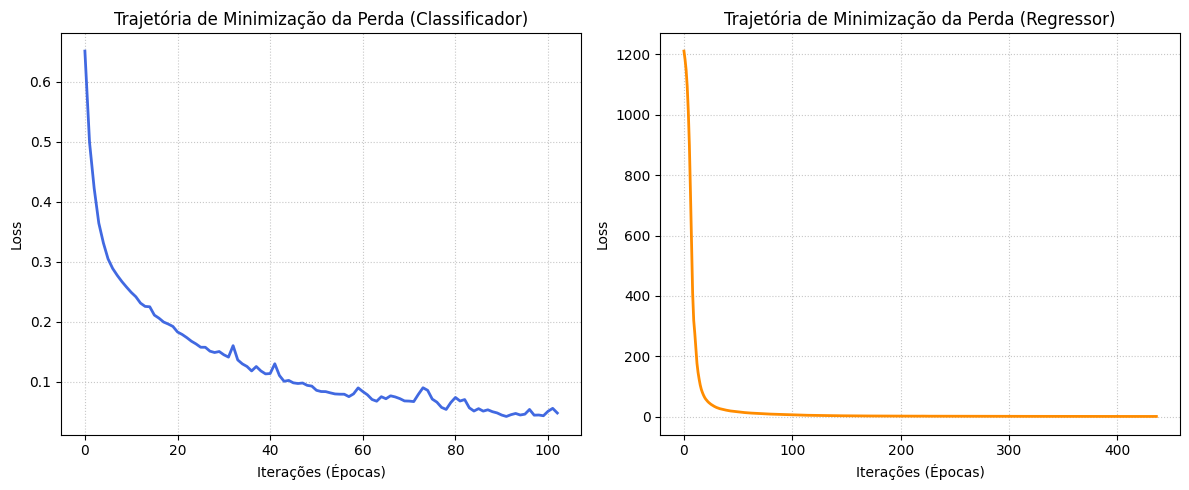

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.metrics import classification_report, confusion_matrix, mean_squared_error, r2_score
import seaborn as sns
import matplotlib.pyplot as plt

# ===================================================================
# 2. ARQUITETURA E HIPERPARÂMETROS DAS REDES NEURAIS (MLP)
# ===================================================================
NEURONIOS_CAMADAS_OCULTAS = (128, 128, 128)
EPOCAS_MAXIMAS = 3000
TAXA_DE_APRENDIZADO = 0.001
TAMANHO_TESTE = 0.2

# ===================================================================
# 2.1. PARTICIONAMENTO DOS DADOS PARA OS MODELOS
# ===================================================================

# --- Modelo Classificador (Previsão do Modo de Falha Estrutural) ---
# Utiliza o conjunto completo para separar as instâncias que romperam das íntegras
X_clf = df[['Massa_TNT_kg', 'Espessura_mm', 'Distancia_Z_mm']]
y_clf = df['Status_Ruptura']

Xc_train, Xc_test, yc_train, yc_test = train_test_split(X_clf, y_clf, test_size=TAMANHO_TESTE, random_state=42)
scaler_clf = StandardScaler()
Xc_train_scaled = scaler_clf.fit_transform(Xc_train)
Xc_test_scaled = scaler_clf.transform(Xc_test)

# --- Modelo Regressor (Previsão do Deslocamento Elasto-plástico Máximo) ---
# Este modelo restringe-se exclusivamente aos casos sem falha catastrófica
df_suportou = df[df['Status_Ruptura'] == 0].copy()
print(f"\nAmostras destinadas à regressão de deslocamento (Íntegras): {len(df_suportou)} de {len(df)}")

X_reg = df_suportou[['Massa_TNT_kg', 'Espessura_mm', 'Distancia_Z_mm']]

# NOTA TÉCNICA (Escalonamento da Variável Alvo):
# O deslocamento natural é extraído em metros (ordem de 10^-3). Valores de magnitude reduzida podem dificultar a
# convergência algorítmica do otimizador base do MLP devido aos micro-gradientes gerados. A conversão da variável
# dependente para milímetros (* 1000) normaliza os dados alvo numa faixa favorável, estabilizando a convergência.
y_reg = df_suportou['Desloc_Eixo_Z_m'] * 1000

Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_reg, y_reg, test_size=TAMANHO_TESTE, random_state=42)
scaler_reg = StandardScaler() # O escalonador é instanciado de forma independente para evitar vazamento de dados.
Xr_train_scaled = scaler_reg.fit_transform(Xr_train)
Xr_test_scaled = scaler_reg.transform(Xr_test)

# ===================================================================
# 2.2. TREINAMENTO DOS MODELOS SUBSTITUTOS (SURROGATE MODELS)
# ===================================================================
print("\nIniciando o treinamento do modelo classificador de falhas...")
clf_ruptura = MLPClassifier(hidden_layer_sizes=NEURONIOS_CAMADAS_OCULTAS, max_iter=EPOCAS_MAXIMAS,
                            learning_rate_init=TAXA_DE_APRENDIZADO, random_state=42)
clf_ruptura.fit(Xc_train_scaled, yc_train)

print("Iniciando o treinamento do modelo de regressão de deslocamento contínuo...")
reg_deslocamento = MLPRegressor(hidden_layer_sizes=NEURONIOS_CAMADAS_OCULTAS, max_iter=EPOCAS_MAXIMAS,
                                learning_rate_init=TAXA_DE_APRENDIZADO, random_state=42)
reg_deslocamento.fit(Xr_train_scaled, yr_train)
print("Processos de convergência concluídos.\n")

# ===================================================================
# 2.3. ANÁLISE DE CONVERGÊNCIA (CURVAS DE PERDA)
# ===================================================================
plt.figure(figsize=(12, 5))

# Evolução do Loss (Classificador Log-Loss)
plt.subplot(1, 2, 1)
plt.plot(clf_ruptura.loss_curve_, color='royalblue', linewidth=2)
plt.title('Trajetória de Minimização da Perda (Classificador)')
plt.xlabel('Iterações (Épocas)')
plt.ylabel('Loss')
plt.grid(True, linestyle=':', alpha=0.7)

# Evolução do Loss (Regressor MSE)
plt.subplot(1, 2, 2)
plt.plot(reg_deslocamento.loss_curve_, color='darkorange', linewidth=2)
plt.title('Trajetória de Minimização da Perda (Regressor)')
plt.xlabel('Iterações (Épocas)')
plt.ylabel('Loss')
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()


In [19]:
from sklearn.model_selection import StratifiedKFold, KFold, cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier, MLPRegressor
import numpy as np

# ===================================================================
# 3. VALIDAÇÃO CRUZADA (K-FOLD)
# ===================================================================
print("====================================================================")
print("             INICIANDO VALIDAÇÃO CRUZADA (K-FOLD = 10)               ")
print("====================================================================")

# 1. Criação dos Pipelines (Prevenção de Data Leakage)
# A estruturação em pipeline assegura que a normalização (StandardScaler)
# seja ajustada estritamente aos dados de treinamento em cada iteração (fold).
pipeline_clf = make_pipeline(
    StandardScaler(),
    MLPClassifier(hidden_layer_sizes=NEURONIOS_CAMADAS_OCULTAS,
                  max_iter=EPOCAS_MAXIMAS,
                  learning_rate_init=TAXA_DE_APRENDIZADO,
                  random_state=42)
)

pipeline_reg = make_pipeline(
    StandardScaler(),
    MLPRegressor(hidden_layer_sizes=NEURONIOS_CAMADAS_OCULTAS,
                 max_iter=EPOCAS_MAXIMAS,
                 learning_rate_init=TAXA_DE_APRENDIZADO,
                 random_state=42)
)

# 2. Configuração dos Particionadores
# Classificador: Aplicação de particionamento estratificado para preservar a distribuição das classes (modos de falha).
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Regressor: K-Fold padrão aplicado ao subconjunto de variáveis contínuas.
kf = KFold(n_splits=10, shuffle=True, random_state=42)

# 3. Execução para o Classificador (Avaliação de Acurácia e F1-Score)
print("Processando validação cruzada para o modelo classificador...")
cv_resultados_clf = cross_validate(pipeline_clf, X_clf, y_clf, cv=skf, scoring=['accuracy', 'f1'])

f1_medio = cv_resultados_clf['test_f1'].mean()
f1_std = cv_resultados_clf['test_f1'].std()
acc_media = cv_resultados_clf['test_accuracy'].mean()

print(f"[CLASSIFICADOR] Acurácia Média: {acc_media:.4f}")
print(f"[CLASSIFICADOR] F1-Score Médio: {f1_medio:.4f} (± {f1_std:.4f})")
print("--------------------------------------------------------------------")

# 4. Execução para o Regressor (Avaliação de R² e Erro Absoluto Médio)
print("Processando validação cruzada para o modelo regressor...")
cv_resultados_reg = cross_validate(pipeline_reg, X_reg, y_reg, cv=kf, scoring=['r2', 'neg_mean_absolute_error'])

r2_medio = cv_resultados_reg['test_r2'].mean()
r2_std = cv_resultados_reg['test_r2'].std()
# O MAE é retornado negativamente por convenção de otimização no scikit-learn.
mae_medio = -cv_resultados_reg['test_neg_mean_absolute_error'].mean()

print(f"[REGRESSOR] R² Médio: {r2_medio:.4f} (± {r2_std:.4f})")
print(f"[REGRESSOR] Erro Médio Absoluto (MAE): {mae_medio:.4f} mm")
print("====================================================================")


             INICIANDO VALIDAÇÃO CRUZADA (K-FOLD = 10)               
Processando validação cruzada para o modelo classificador...
[CLASSIFICADOR] Acurácia Média: 0.9687
[CLASSIFICADOR] F1-Score Médio: 0.9236 (± 0.0438)
--------------------------------------------------------------------
Processando validação cruzada para o modelo regressor...
[REGRESSOR] R² Médio: 0.9955 (± 0.0018)
[REGRESSOR] Erro Médio Absoluto (MAE): 1.6045 mm


### 3.1. COMPARAÇÃO COM OUTROS MODELOS CLÁSSICOS (BENCHMARKING)

Comparativo direto de desempenho entre as Redes Neurais (MLP) e outros algoritmos tradicionais de Machine Learning (Random Forest, SVR e Regressão Logística) para atestar a robustez da arquitetura escolhida.

In [37]:
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.svm import SVR
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

print("====================================================================")
print("          COMPARAÇÃO DE DESEMPENHO COM OUTROS ALGORITMOS            ")
print("====================================================================")

# Comparação do Regressor (Deslocamento)
models_reg = {
    'MLP (Atual)': pipeline_reg,
    'Random Forest': make_pipeline(StandardScaler(), RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
    'SVR': make_pipeline(StandardScaler(), SVR(kernel='rbf'))
}

print("--- COMPARAÇÃO REGRESSOR (MSE / R2 / MAE) ---")
for name, model in models_reg.items():
    # Utilizando o particionador KFold (kf) instanciado na célula anterior
    cv = cross_validate(model, X_reg, y_reg, cv=kf, scoring=['r2', 'neg_mean_absolute_error'], n_jobs=-1)
    print(f"{name:>15}: R2 = {cv['test_r2'].mean():.4f} | MAE = {-cv['test_neg_mean_absolute_error'].mean():.4f} mm")

# Comparação do Classificador (Ruptura)
models_clf = {
    'MLP (Atual)': pipeline_clf,
    'Random Forest': make_pipeline(StandardScaler(), RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
    'Logistic Reg': make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=42))
}

print("\n--- COMPARAÇÃO CLASSIFICADOR (Acurácia / F1) ---")
for name, model in models_clf.items():
    # Utilizando o particionador Estratificado (skf) instanciado na célula anterior
    cv = cross_validate(model, X_clf, y_clf, cv=skf, scoring=['accuracy', 'f1'], n_jobs=-1)
    print(f"{name:>15}: Acc = {cv['test_accuracy'].mean():.4f} | F1 = {cv['test_f1'].mean():.4f}")

print("====================================================================")

          COMPARAÇÃO DE DESEMPENHO COM OUTROS ALGORITMOS            
--- COMPARAÇÃO REGRESSOR (MSE / R2 / MAE) ---
    MLP (Atual): R2 = 0.9955 | MAE = 1.6045 mm
  Random Forest: R2 = 0.9750 | MAE = 3.2844 mm
            SVR: R2 = 0.8620 | MAE = 8.9626 mm

--- COMPARAÇÃO CLASSIFICADOR (Acurácia / F1) ---
    MLP (Atual): Acc = 0.9687 | F1 = 0.9236
  Random Forest: Acc = 0.9313 | F1 = 0.8294
   Logistic Reg: Acc = 0.8620 | F1 = 0.6720


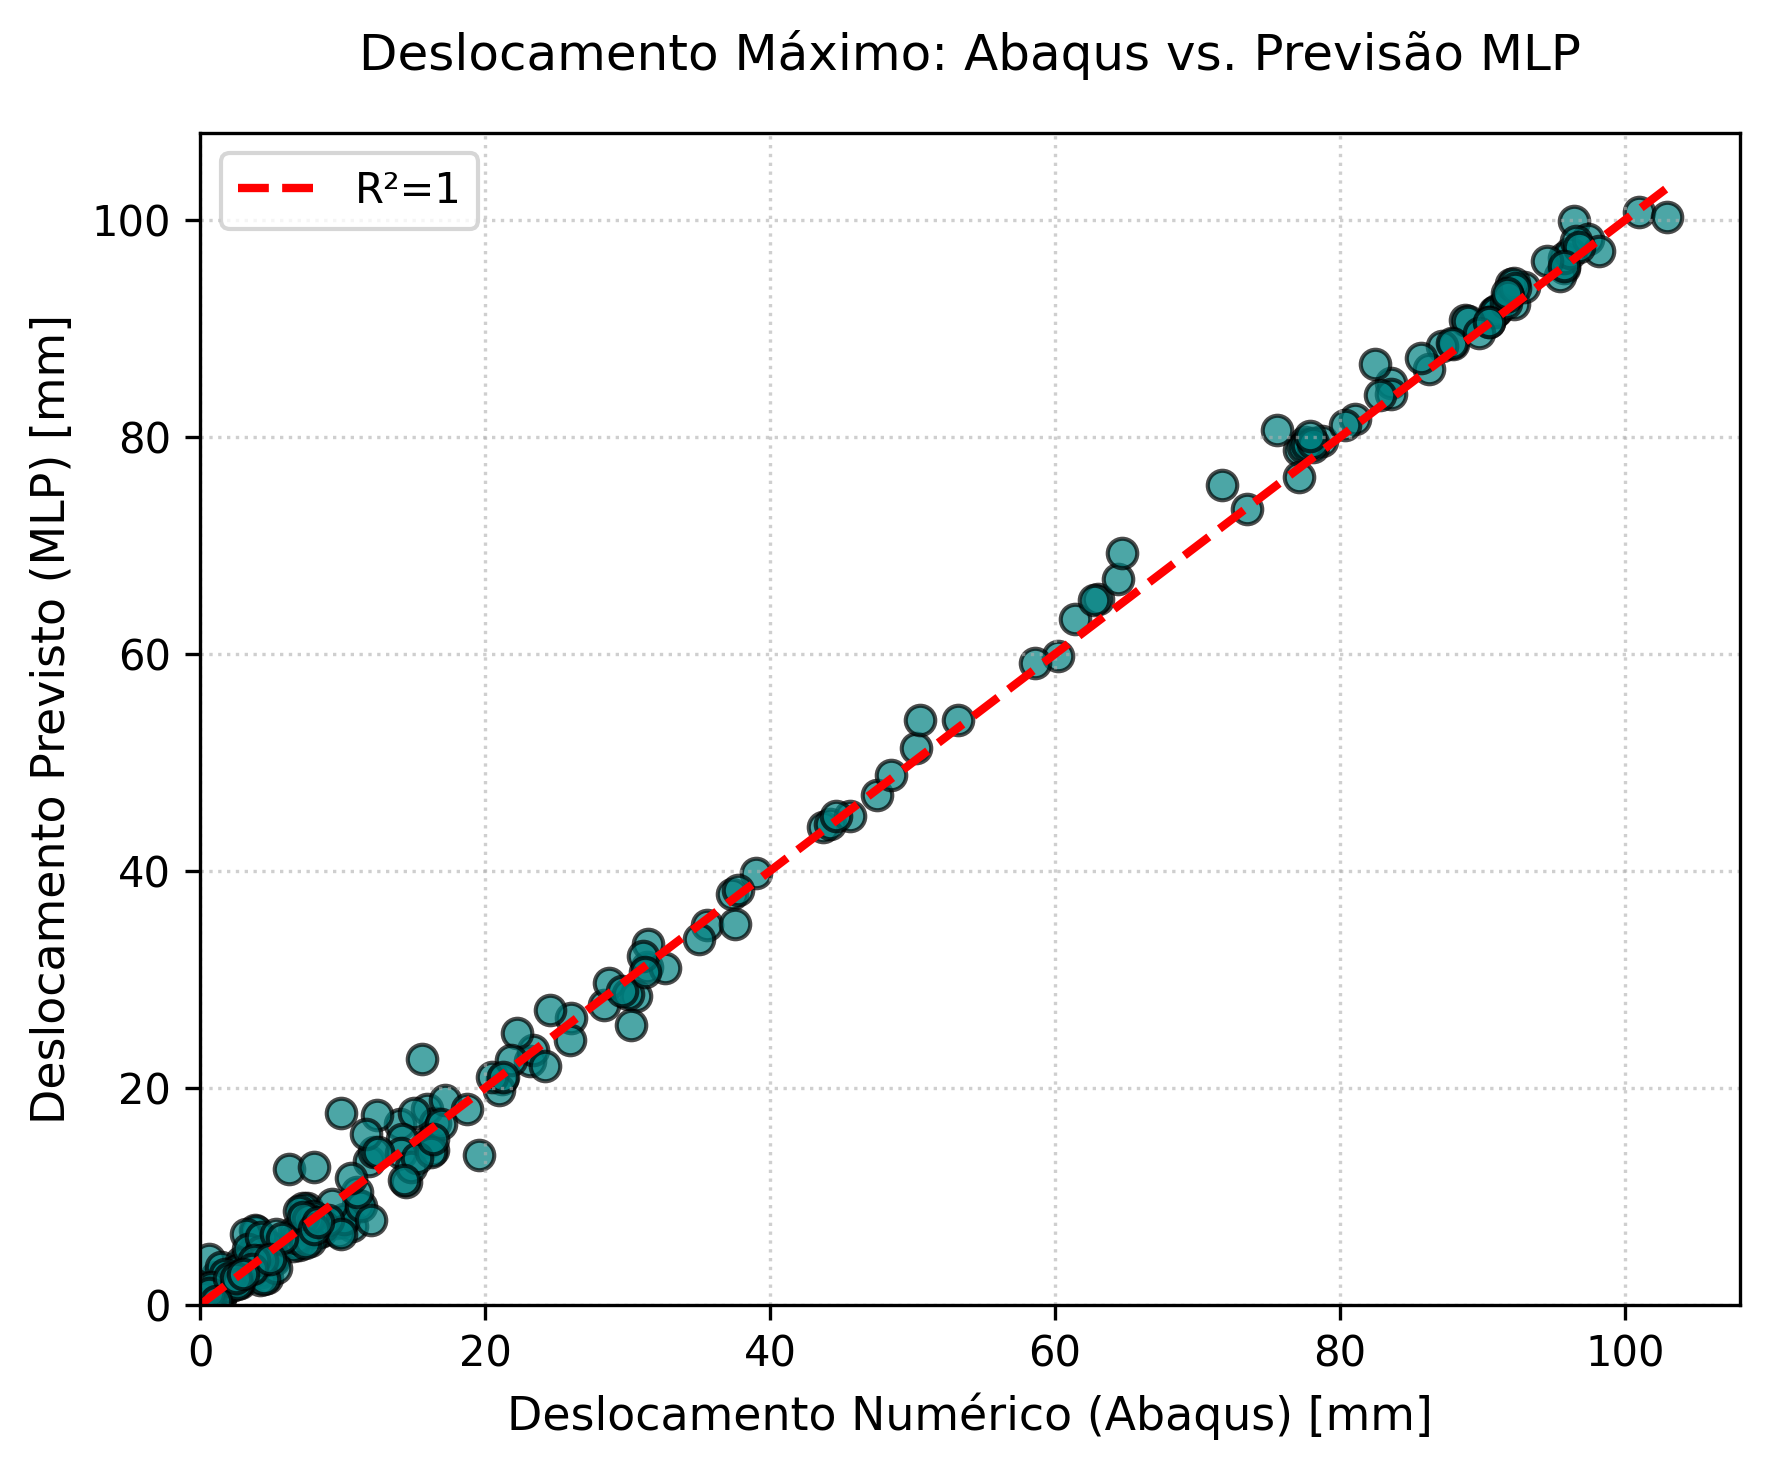

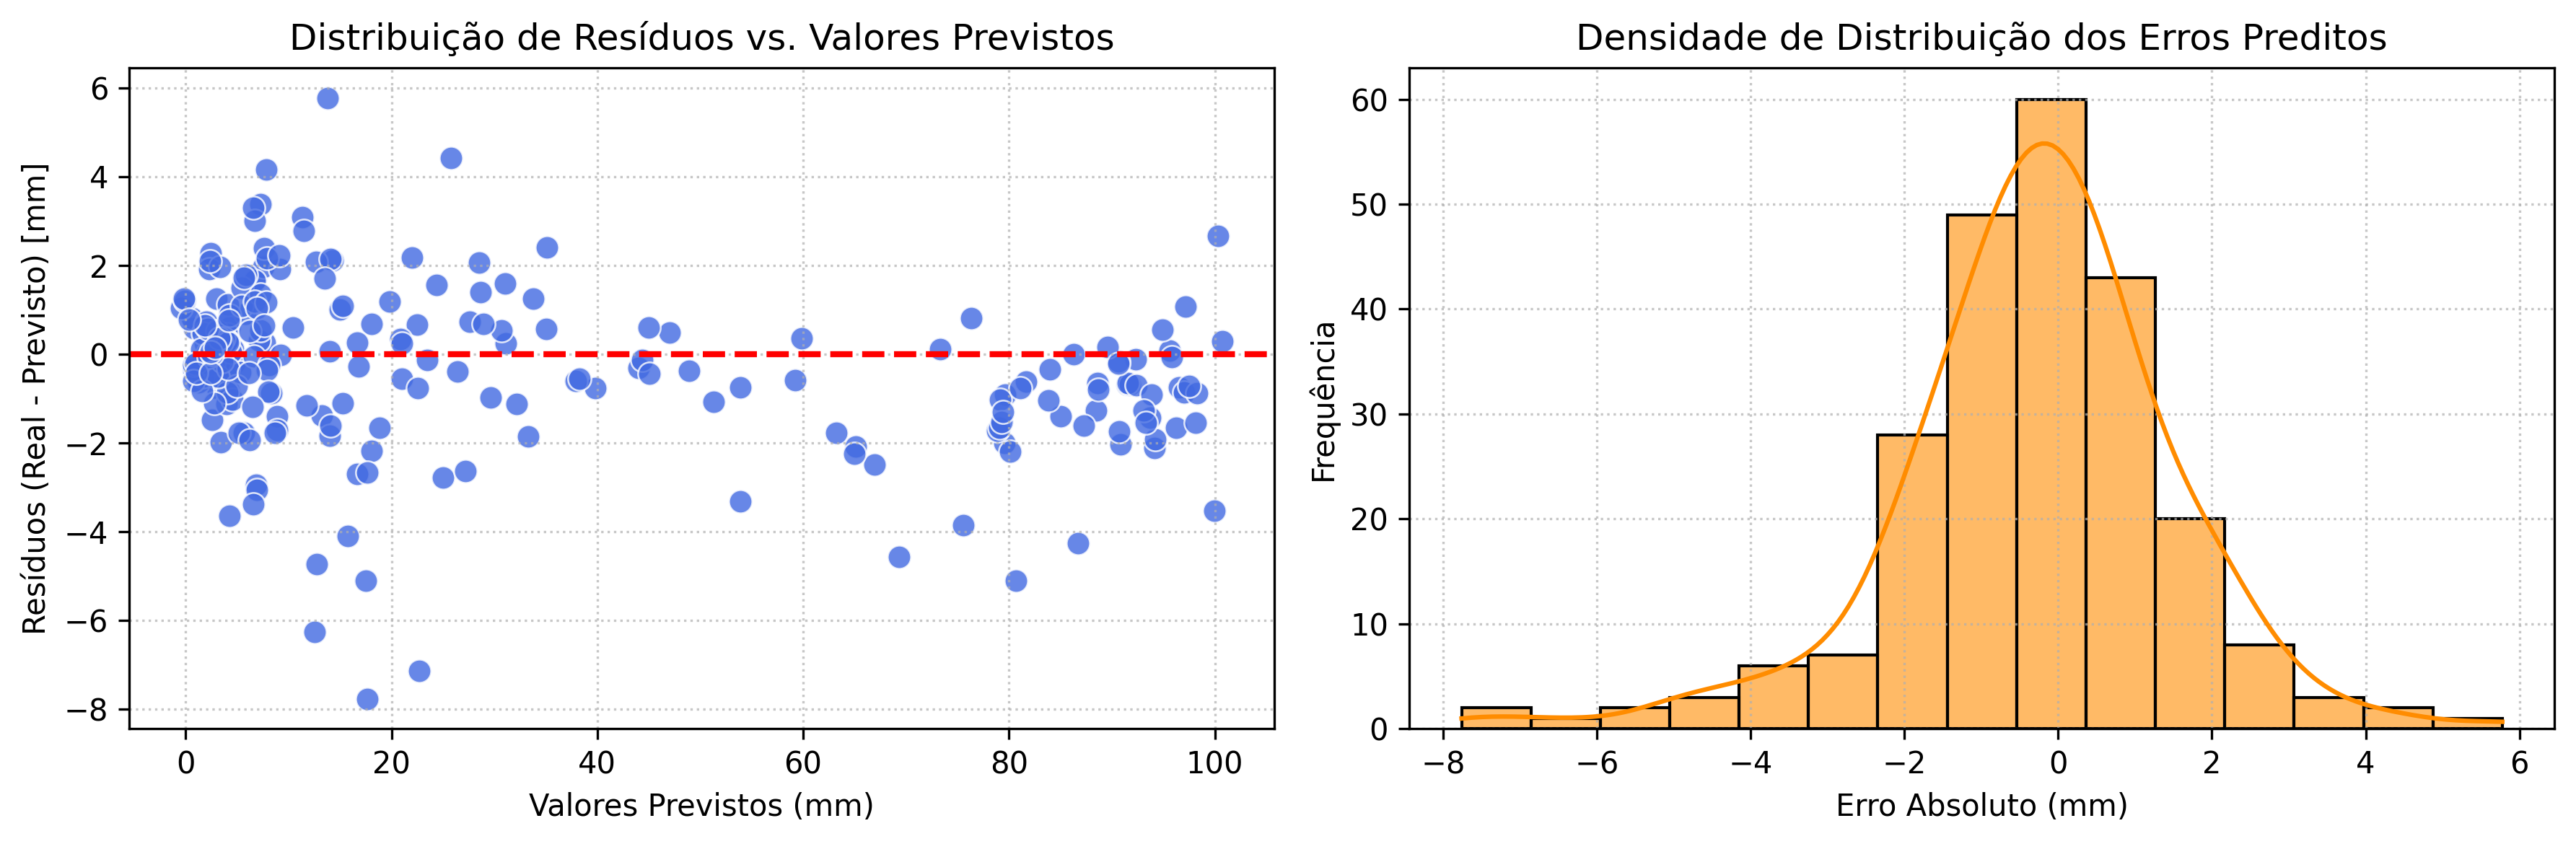


MÉTRICAS DE DESEMPENHO DO CLASSIFICADOR (FALHA ESTRUTURAL)
              precision    recall  f1-score   support

 Íntegra (0)       0.98      0.99      0.99       232
   Falha (1)       0.97      0.93      0.95        68

    accuracy                           0.98       300
   macro avg       0.97      0.96      0.97       300
weighted avg       0.98      0.98      0.98       300



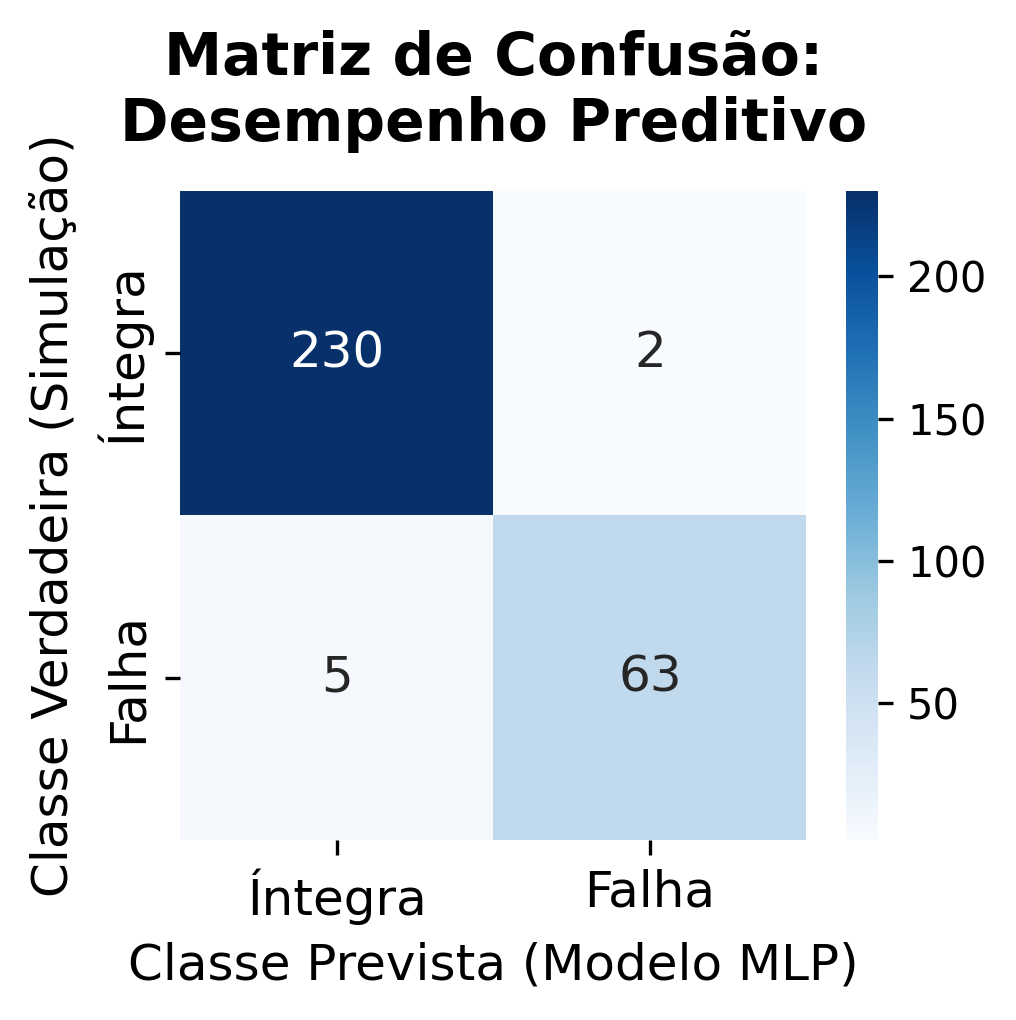

In [20]:
# ===================================================================
# 4. AVALIAÇÃO E MÉTRICAS DE DESEMPENHO DOS MODELOS
# ===================================================================

# --- 4.1. AVALIAÇÃO DO MODELO DE REGRESSÃO (DESLOCAMENTO ELASTO-PLÁSTICO) ---
yr_pred_mm = reg_deslocamento.predict(Xr_test_scaled)
yr_test_mm = yr_test

mse = mean_squared_error(yr_test_mm, yr_pred_mm)
r2 = r2_score(yr_test_mm, yr_pred_mm)
mae = np.mean(np.abs(yr_test_mm - yr_pred_mm))

# Cálculo dos resíduos preditivos
residuos = yr_test_mm - yr_pred_mm

# Gráfico de Dispersão: Predição vs. Realidade Numérica
plt.figure(figsize=(6, 5), dpi=300)
plt.scatter(yr_test_mm, yr_pred_mm, alpha=0.7, color='teal', edgecolors='k', s=50)
max_val = max(yr_test_mm.max(), yr_pred_mm.max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=2, label='R²=1')
plt.title('Deslocamento Máximo: Abaqus vs. Previsão MLP', fontsize=12, pad=15)
plt.xlabel('Deslocamento Numérico (Abaqus) [mm]', fontsize=11)
plt.ylabel('Deslocamento Previsto (MLP) [mm]', fontsize=11)
plt.xlim(0, max_val * 1.05)
plt.ylim(0, max_val * 1.05)
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=300)

# Gráfico de Resíduos vs. Valores Previstos
sns.scatterplot(x=yr_pred_mm, y=residuos, ax=axes[0], color='royalblue', alpha=0.8, s=60, edgecolor='w')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0].set_title('Distribuição de Resíduos vs. Valores Previstos')
axes[0].set_xlabel('Valores Previstos (mm)')
axes[0].set_ylabel('Resíduos (Real - Previsto) [mm]')
axes[0].grid(True, linestyle=':', alpha=0.7)

# Histograma da Distribuição de Resíduos
sns.histplot(residuos, kde=True, ax=axes[1], color='darkorange', bins=15, alpha=0.6)
axes[1].set_title('Densidade de Distribuição dos Erros Preditos')
axes[1].set_xlabel('Erro Absoluto (mm)')
axes[1].set_ylabel('Frequência')
axes[1].grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

# ===================================================================
# --- 4.2. AVALIAÇÃO DO CLASSIFICADOR E INTERPRETAÇÃO DA MATRIZ DE CONFUSÃO ---
# ===================================================================

# Interpretação dos Modos Preditos:
# 1. Verdadeiros Negativos (0,0): Modelo prevê integridade; simulação confirma.
# 2. Verdadeiros Positivos (1,1): Modelo prevê falha; simulação confirma.
# 3. Falsos Positivos (1,0): Modelo prevê falha, mas a estrutura permanece íntegra.
#    - Caracterização: Erro conservador. Tende ao superdimensionamento paramétrico, preservando a segurança.
# 4. Falsos Negativos (0,1): Modelo prevê integridade, mas ocorre falha catastrófica.
#    - Caracterização: Erro crítico (Inseguro). Subestimação dos limites estruturais, incorrendo em risco de colapso.

print("\n" + "="*60)
print("MÉTRICAS DE DESEMPENHO DO CLASSIFICADOR (FALHA ESTRUTURAL)")
print("="*60)
yc_pred = clf_ruptura.predict(Xc_test_scaled)
print(classification_report(yc_test, yc_pred, target_names=['Íntegra (0)', 'Falha (1)']))

plt.figure(figsize=(3.5, 3.5), dpi=300)
sns.heatmap(confusion_matrix(yc_test, yc_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Íntegra', 'Falha'], yticklabels=['Íntegra', 'Falha'],
            annot_kws={"size": 12})
plt.title('Matriz de Confusão:\nDesempenho Preditivo', fontweight='bold', fontsize=14, pad=12)
plt.ylabel('Classe Verdadeira (Simulação)', fontsize=12)
plt.xlabel('Classe Prevista (Modelo MLP)', fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()


------------------------------------------------------------
CENÁRIO ANALISADO: 1.8 kg TNT | Espessura: 5.0 mm | Z = 400 mm
------------------------------------------------------------
Previsão do Modelo: ESTRUTURA ÍNTEGRA
Probabilidade Associada à Falha: 0.0%
Deslocamento Máximo Estimado (Eixo Z): 53.25 mm
------------------------------------------------------------


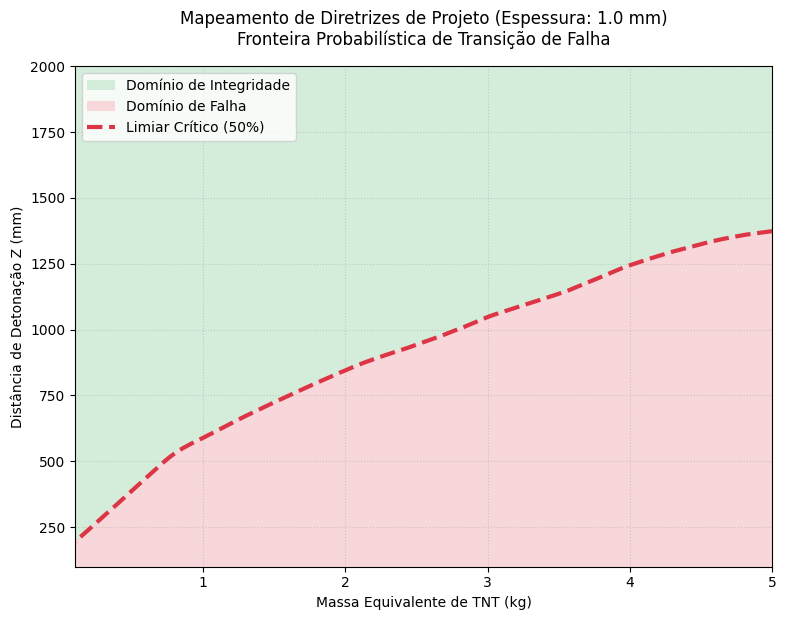

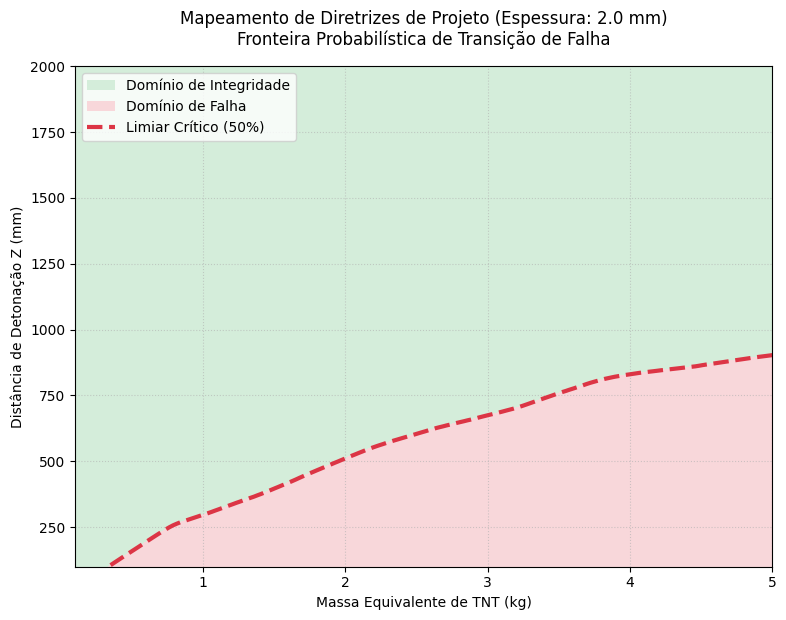

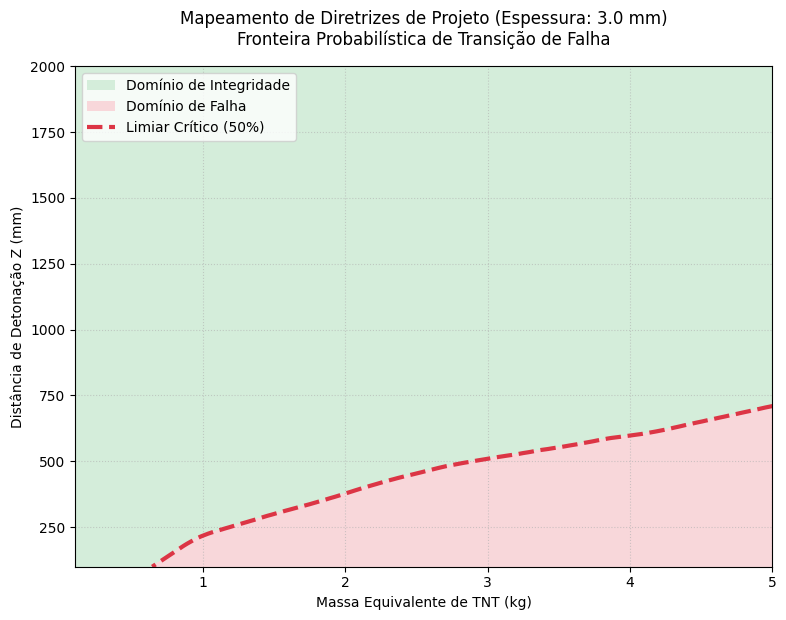

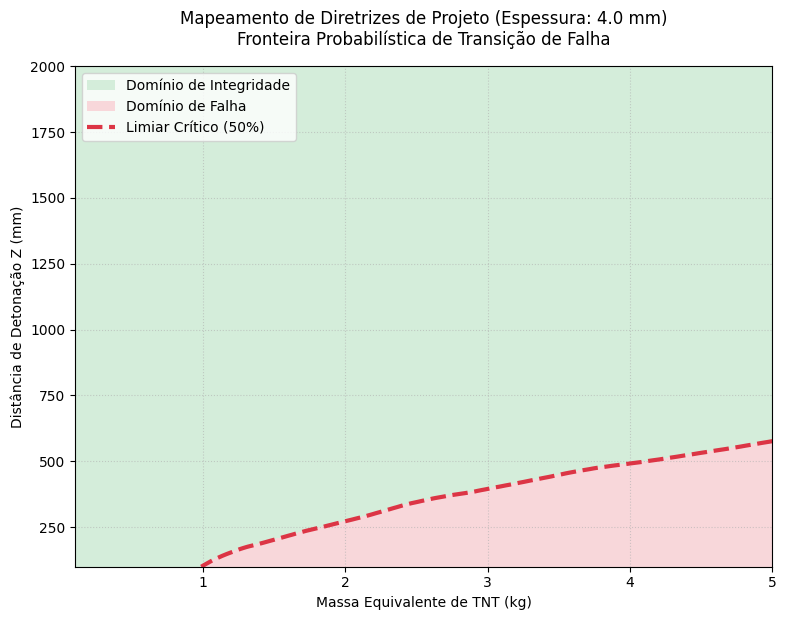

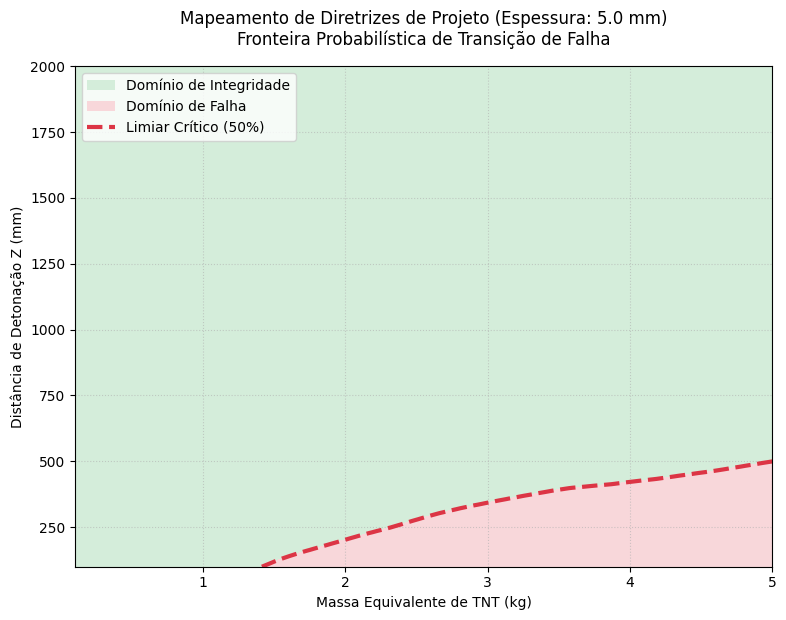

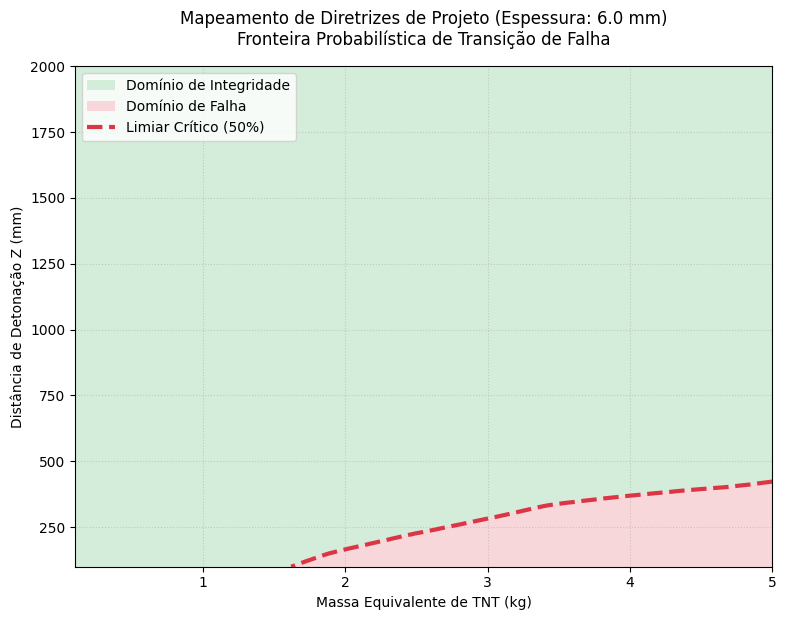

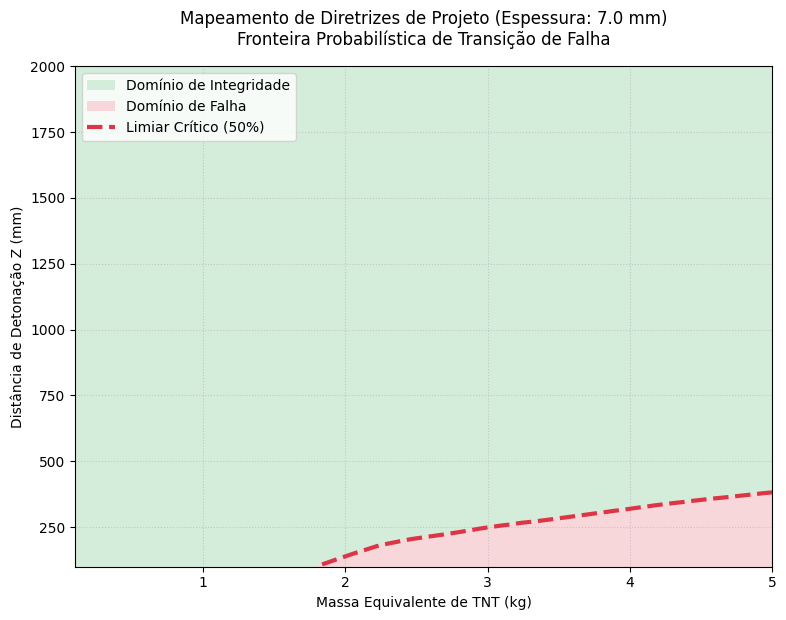

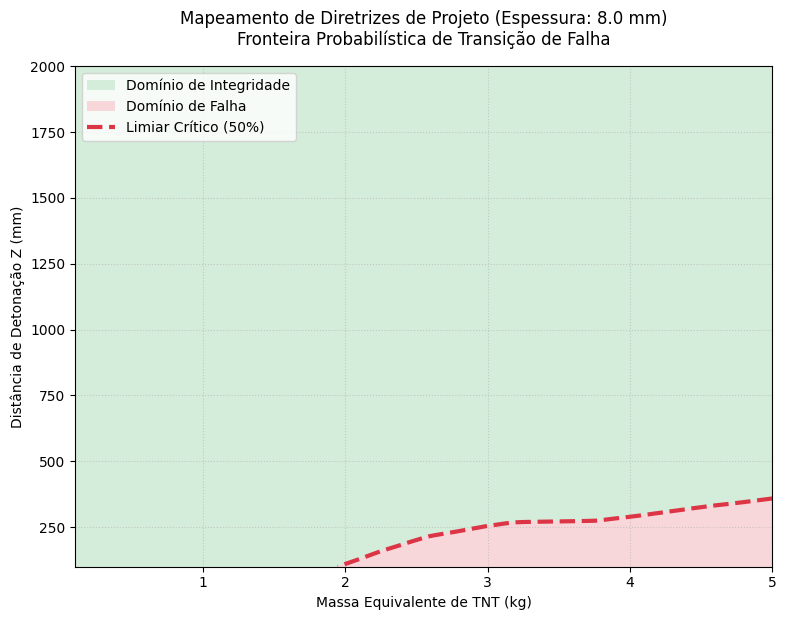

In [21]:
# ===================================================================
# 5. FERRAMENTAS DE PREDIÇÃO PARA O MODELO SUBSTITUTO
# ===================================================================

def avaliar_estado_estrutural(massa_kg, esp_mm, dist_z_mm):
    """Realiza a predição pontual do modo de falha e deslocamento para um cenário específico."""
    df_entrada = pd.DataFrame([[massa_kg, esp_mm, dist_z_mm]], columns=['Massa_TNT_kg', 'Espessura_mm', 'Distancia_Z_mm'])

    # 1. Avaliação do limiar de ruptura (Classificação)
    entrada_clf_scaled = scaler_clf.transform(df_entrada)
    prob_falha = clf_ruptura.predict_proba(entrada_clf_scaled)[0][1] * 100
    classe_predita = clf_ruptura.predict(entrada_clf_scaled)[0]

    print("-" * 60)
    print(f"CENÁRIO ANALISADO: {massa_kg} kg TNT | Espessura: {esp_mm} mm | Z = {dist_z_mm} mm")
    print("-" * 60)

    if classe_predita == 1:
        print("Previsão do Modelo: FALHA CATASTRÓFICA (Ruptura)")
        print(f"Probabilidade Associada à Falha: {prob_falha:.1f}%")
        print("Deslocamento Máximo: Não aplicável (Estrutura comprometida).")
    else:
        # 2. Avaliação da resposta elasto-plástica (Regressão)
        entrada_reg_scaled = scaler_reg.transform(df_entrada)
        deslocamento_mm = reg_deslocamento.predict(entrada_reg_scaled)[0]

        print("Previsão do Modelo: ESTRUTURA ÍNTEGRA")
        print(f"Probabilidade Associada à Falha: {prob_falha:.1f}%")
        print(f"Deslocamento Máximo Estimado (Eixo Z): {deslocamento_mm:.2f} mm")
    print("-" * 60)

# --- AVALIAÇÃO DE CENÁRIO PONTUAL ---
avaliar_estado_estrutural(massa_kg=1.8, esp_mm=5.0, dist_z_mm=400)

def plotar_fronteira_decisao(espessura_alvo):
    """Gera o mapeamento das zonas de falha e integridade para uma espessura nominal fixa."""
    massas = np.linspace(0.1, 5, 200)
    distancias = np.linspace(100, 2000, 200)
    M, Z = np.meshgrid(massas, distancias)

    df_sweep = pd.DataFrame({'Massa_TNT_kg': M.ravel(), 'Espessura_mm': espessura_alvo, 'Distancia_Z_mm': Z.ravel()})
    P = clf_ruptura.predict_proba(scaler_clf.transform(df_sweep))[:, 1].reshape(M.shape)

    plt.figure(figsize=(9, 6.5))
    plt.contourf(M, Z, P, levels=[0.0, 0.5, 1.0], colors=['#d4edda', '#f8d7da'])
    contorno = plt.contour(M, Z, P, levels=[0.5], colors=['#dc3545'], linewidths=[3], linestyles=['dashed'])

    plt.title(f'Mapeamento de Diretrizes de Projeto (Espessura: {espessura_alvo} mm)\nFronteira Probabilística de Transição de Falha', pad=15)
    plt.xlabel('Massa Equivalente de TNT (kg)')
    plt.ylabel('Distância de Detonação Z (mm)')

    proxy_seguro = plt.Rectangle((0,0),1,1,fc='#d4edda')
    proxy_falha = plt.Rectangle((0,0),1,1,fc='#f8d7da')
    proxy_contorno = plt.Line2D([0], [0], color='#dc3545', linewidth=3, linestyle='dashed')

    plt.legend([proxy_seguro, proxy_falha, proxy_contorno],
               ['Domínio de Integridade', 'Domínio de Falha', 'Limiar Crítico (50%)'], loc='upper left')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()

# Execução iterativa para mapeamento de parâmetros comerciais padrão
for esp in range(1, 9):
    plotar_fronteira_decisao(espessura_alvo=float(esp))


[INFO] Computando varredura multiparamétrica via MLP Classificadora...


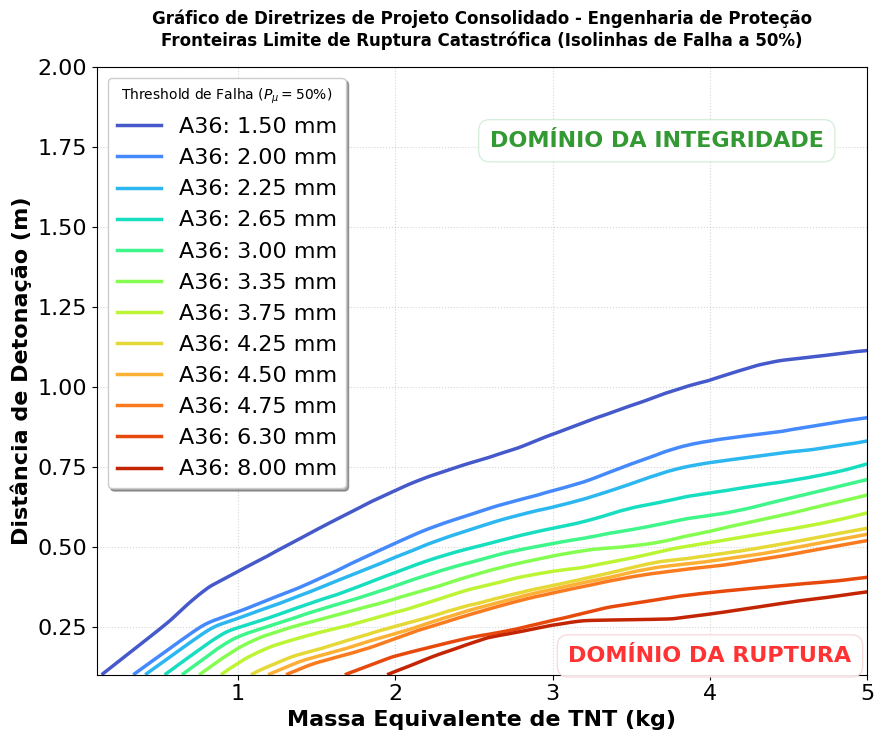

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===================================================================
# 6. MAPEAMENTO CONSOLIDADO DAS FRONTEIRAS DE DECISÃO
# ===================================================================

def gerar_grafico_consolidado_fronteiras():
    """
    Agrega as curvas limítrofes (probabilidade de falha P = 50%) para
    diferentes espessuras nominais em um único espaço paramétrico de projeto.
    """
    # 1. Definição do espaço de estados paramétricos
    massas = np.linspace(0.1, 5, 250)
    distancias = np.linspace(100, 2000, 250)
    M, Z = np.meshgrid(massas, distancias)

    # Espessuras comerciais representativas do estudo
    espessuras = np.array([1.50, 2.00, 2.25, 2.65, 3.00, 3.35, 3.75, 4.25, 4.50, 4.75, 6.30, 8.00])

    # 2. Inicialização e configuração visual da figura (Padrão de Publicação)
    plt.figure(figsize=(9, 7.5), dpi=100)
    valores_normalizados = np.linspace(0.1, 0.9, len(espessuras))
    paleta_cores = plt.cm.turbo(valores_normalizados)

    print("[INFO] Computando varredura multiparamétrica via MLP Classificadora...")

    # 3. Iteração para construção das isolinhas por espessura
    for idx, esp in enumerate(espessuras):
        df_sweep = pd.DataFrame({
            'Massa_TNT_kg': M.ravel(),
            'Espessura_mm': float(esp),
            'Distancia_Z_mm': Z.ravel()
        })

        # Inferência do modelo substituto sobre a malha de estados
        dados_escalados = scaler_clf.transform(df_sweep)
        P = clf_ruptura.predict_proba(dados_escalados)[:, 1].reshape(M.shape)

        # Traçado da isolinha limítrofe (Eixo Y em metros)
        plt.contour(M, Z/1000, P, levels=[0.5], colors=[paleta_cores[idx]], linewidths=[2.5])
        plt.plot([], [], color=paleta_cores[idx], linewidth=2.5, label=f'A36: {esp:.2f} mm')

    # 4. Formatação de eixos e inserção de metadados interpretativos
    plt.title('Gráfico de Diretrizes de Projeto Consolidado - Engenharia de Proteção\nFronteiras Limite de Ruptura Catastrófica (Isolinhas de Falha a 50%)',
              pad=15, fontsize=12, fontweight='bold')

    plt.xlabel('Massa Equivalente de TNT (kg)', fontsize=16, fontweight='semibold')
    plt.ylabel('Distância de Detonação (m)', fontsize=16, fontweight='semibold')
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)

    # Demarcação visual das zonas de comportamento
    plt.text(2.6, 1.75, 'DOMÍNIO DA INTEGRIDADE',
             fontsize=16, color='green', weight='bold', alpha=0.8,
             bbox=dict(facecolor='white', alpha=0.9, boxstyle='round,pad=0.5', edgecolor='#d4edda'))

    plt.text(3.1, 0.14, 'DOMÍNIO DA RUPTURA',
             fontsize=16, color='red', weight='bold', alpha=0.8,
             bbox=dict(facecolor='white', alpha=0.9, boxstyle='round,pad=0.5', edgecolor='#f8d7da'))

    plt.grid(True, linestyle=':', alpha=0.5)
    plt.legend(title=r'Threshold de Falha ($P_{\mu} = 50\%$)', loc='upper left', frameon=True, shadow=True, fontsize=16)

    plt.xlim(0.1, 5)
    plt.ylim(0.1, 2.0)
    plt.tight_layout()
    plt.show()

gerar_grafico_consolidado_fronteiras()


In [23]:
import pickle
import pandas as pd
import os
import gdown

# ===================================================================
# 10. PERSISTÊNCIA E RESTAURAÇÃO DOS MODELOS PREDITIVOS
# ===================================================================
url_modelos = 'https://drive.google.com/drive/folders/1_ooZeB71e_gW9UZUDjfXP5WtFXswwwPj?usp=sharing'
dir_modelos = '/content/Modelos'

print("[INFO] Sincronizando repositório de modelos estruturais...")
if not os.path.exists(dir_modelos):
    gdown.download_folder(url_modelos, output=dir_modelos, quiet=False, use_cookies=False)

# Serialização em disco para garantir a reprodutibilidade dos resultados
os.makedirs(dir_modelos, exist_ok=True)
with open(f'{dir_modelos}/clf_ruptura.pkl', 'wb') as f:
    pickle.dump(clf_ruptura, f)
with open(f'{dir_modelos}/scaler_clf.pkl', 'wb') as f:
    pickle.dump(scaler_clf, f)
with open(f'{dir_modelos}/reg_deslocamento.pkl', 'wb') as f:
    pickle.dump(reg_deslocamento, f)
with open(f'{dir_modelos}/scaler_reg.pkl', 'wb') as f:
    pickle.dump(scaler_reg, f)

# ===================================================================
# CARREGAMENTO EM MEMÓRIA PARA INFERÊNCIA POSTERIOR
# ===================================================================

print("[INFO] Restaurando instâncias dos modelos e escalonadores...")

# Deserialização do modelo classificador e de seu respectivo transformador
with open(f'{dir_modelos}/clf_ruptura.pkl', 'rb') as f:
    clf_carregado = pickle.load(f)

with open(f'{dir_modelos}/scaler_clf.pkl', 'rb') as f:
    scaler_clf_carregado = pickle.load(f)

print("[OK] Artefatos preditivos carregados no ambiente com sucesso.\n")


[INFO] Sincronizando repositório de modelos estruturais...
[INFO] Restaurando instâncias dos modelos e escalonadores...
[OK] Artefatos preditivos carregados no ambiente com sucesso.



In [24]:
import pickle
import pandas as pd
import numpy as np
from IPython.display import display

# ===================================================================
# 7. INFERÊNCIA MULTIPARAMÉTRICA (ANÁLISE DE CENÁRIOS EM LOTE)
# ===================================================================

# 1. Restauração dos modelos preditivos consolidados
dir_modelos = '/content/Modelos'

with open(f'{dir_modelos}/clf_ruptura.pkl', 'rb') as f:
    clf_batch = pickle.load(f)
with open(f'{dir_modelos}/scaler_clf.pkl', 'rb') as f:
    scaler_clf_batch = pickle.load(f)

with open(f'{dir_modelos}/reg_deslocamento.pkl', 'rb') as f:
    reg_batch = pickle.load(f)
with open(f'{dir_modelos}/scaler_reg.pkl', 'rb') as f:
    scaler_reg_batch = pickle.load(f)

def analisar_lote_cenarios(df_cenarios):
    """
    Avalia simultaneamente uma matriz de cenários operacionais.
    Retorna o modo de falha predito e, para estruturas íntegras, o deslocamento elasto-plástico.
    """
    print(f"[INFO] Processando matriz de cenários: {len(df_cenarios)} instâncias submetidas.")
    resultados = df_cenarios.copy()

    # --- PREDIÇÃO DE ESTADO ESTRUTURAL (RUPTURA) ---
    X_clf_scaled = scaler_clf_batch.transform(df_cenarios)
    previsoes_ruptura = clf_batch.predict(X_clf_scaled)
    probabilidades_ruptura = clf_batch.predict_proba(X_clf_scaled)[:, 1] * 100

    # --- PREDIÇÃO DE RESPOSTA MECÂNICA (DESLOCAMENTO) ---
    X_reg_scaled = scaler_reg_batch.transform(df_cenarios)
    previsoes_flecha = reg_batch.predict(X_reg_scaled)

    # --- CONSOLIDAÇÃO DOS RESULTADOS ---
    resultados['Prob_Ruptura_%'] = np.round(probabilidades_ruptura, 2)
    resultados['Modo_Predito'] = ["FALHA" if p == 1 else "ÍNTEGRA" for p in previsoes_ruptura]

    # O cálculo de deslocamento é semanticamente inválido para estruturas colapsadas
    resultados['Deslocamento_Z_mm'] = [
        f"{f:.2f}" if p == 0 else "N/A"
        for p, f in zip(previsoes_ruptura, previsoes_flecha)
    ]

    return resultados

# ===================================================================
# DEMONSTRAÇÃO PRÁTICA DA ROTINA DE ANÁLISE EM LOTE
# ===================================================================

# Construção de uma amostragem representativa cobrindo diferentes domínios do problema
matriz_experimentos = pd.DataFrame([
    [1.5, 4.0, 500],   # Cenário nominal intermediário
    [4.5, 2.0, 200],   # Cenário severo (alta energia incidente, baixa inércia)
    [0.5, 8.0, 1500],  # Cenário conservador (baixa energia, alta inércia)
    [2.0, 5.0, 800],   # Cenário operacional A
    [3.5, 4.5, 600]    # Cenário operacional B
], columns=['Massa_TNT_kg', 'Espessura_mm', 'Distancia_Z_mm'])

# Execução preditiva vetorizada
tabela_resultados = analisar_lote_cenarios(matriz_experimentos)

print("\n--- RELATÓRIO DE AVALIAÇÃO MULTIPARAMÉTRICA ---")
display(tabela_resultados)


[INFO] Processando matriz de cenários: 5 instâncias submetidas.

--- RELATÓRIO DE AVALIAÇÃO MULTIPARAMÉTRICA ---


,Massa_TNT_kg,Espessura_mm,Distancia_Z_mm,Prob_Ruptura_%,Modo_Predito,Deslocamento_Z_mm
0,1.5,4.0,500,0.0,ÍNTEGRA,42.51
1,4.5,2.0,200,100.0,FALHA,N/A
2,0.5,8.0,1500,0.0,ÍNTEGRA,2.43
3,2.0,5.0,800,0.0,ÍNTEGRA,21.87
4,3.5,4.5,600,0.0,ÍNTEGRA,60.28


[INFO] Executando análise de sensibilidade via permutação nos modelos substitutos...


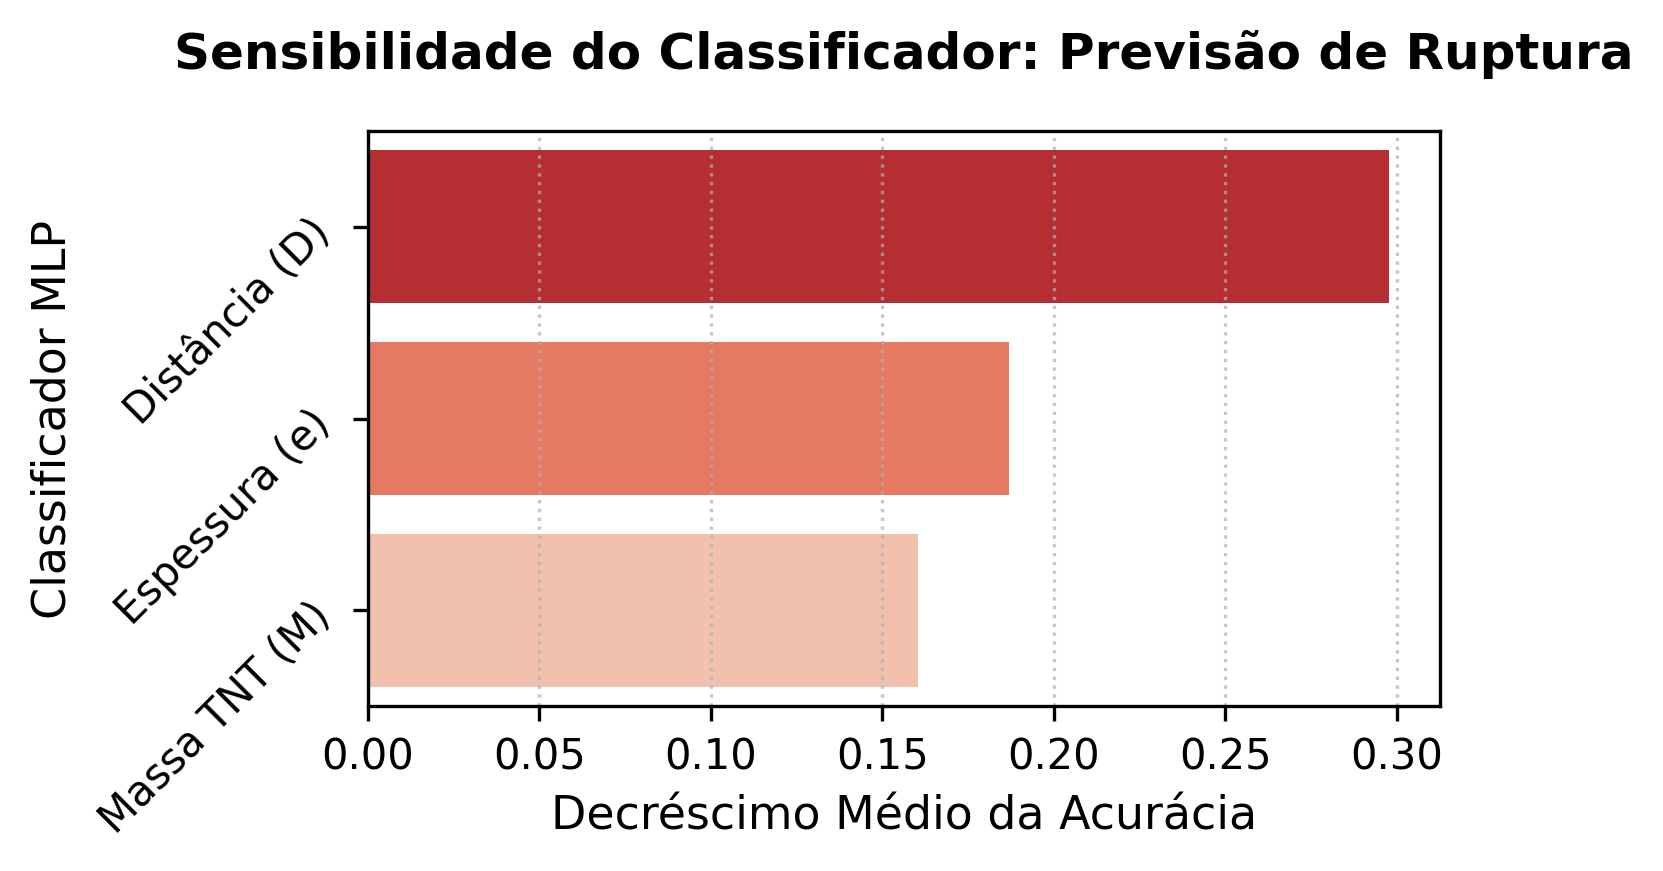

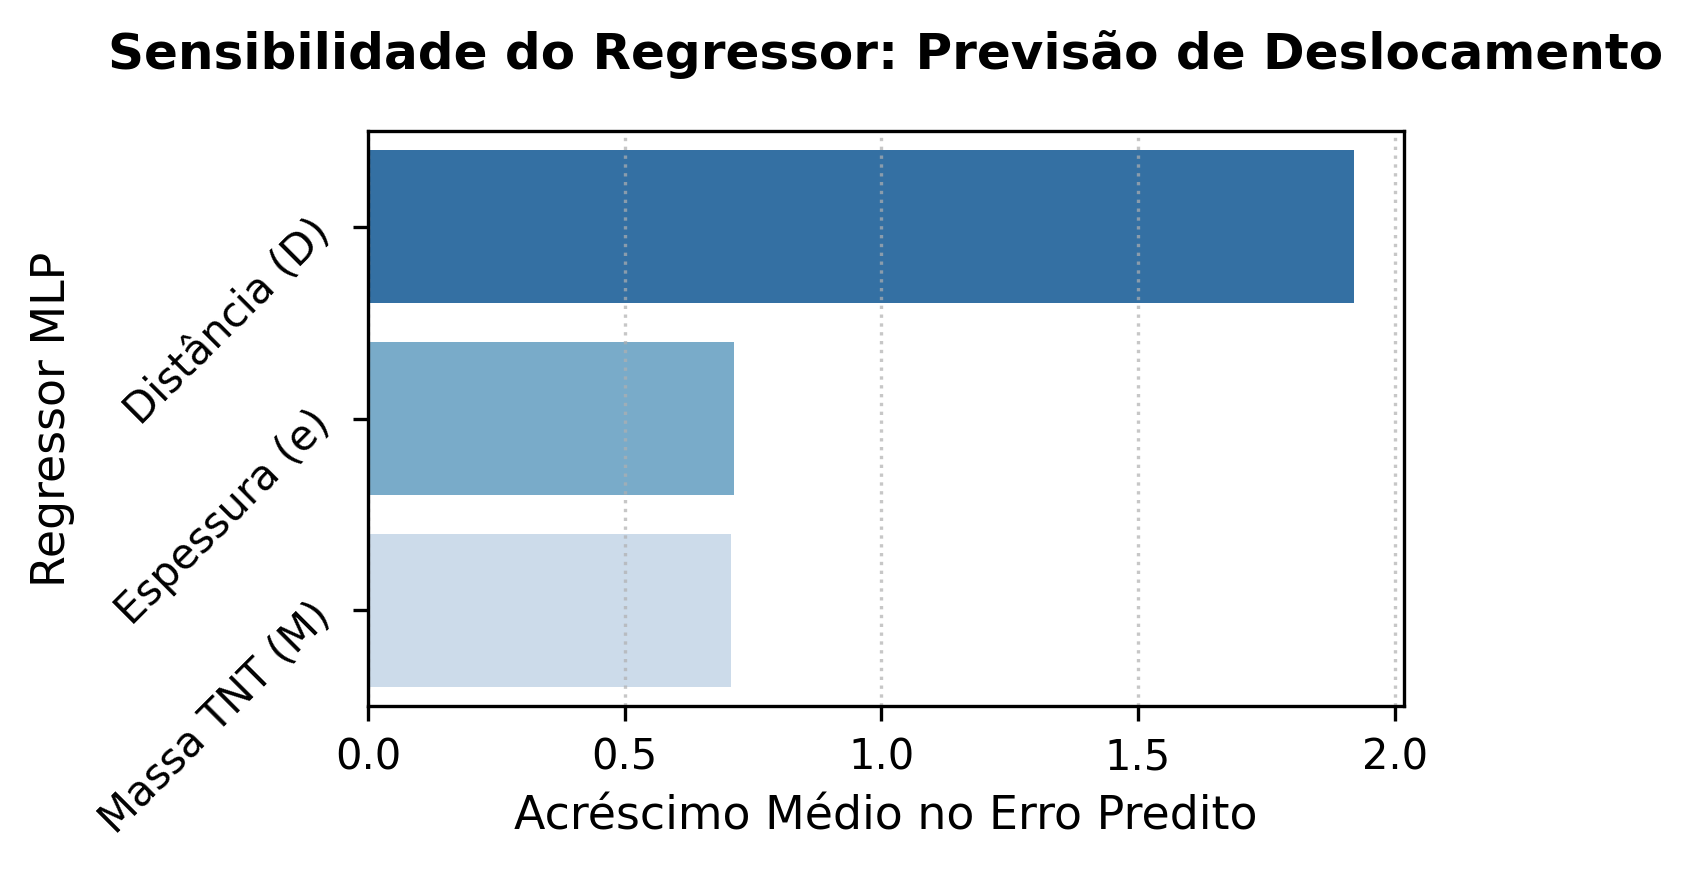

In [25]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ===================================================================
# 11. ANÁLISE DE SENSIBILIDADE PARAMÉTRICA (PERMUTATION IMPORTANCE)
# ===================================================================

nomes_features = ['Massa TNT (M)', 'Espessura (e)', 'Distância (D)']

print("[INFO] Executando análise de sensibilidade via permutação nos modelos substitutos...")

# 1. Sensibilidade para o Modelo de Classificação (Ruptura)
resultado_clf = permutation_importance(clf_ruptura, Xc_test_scaled, yc_test, n_repeats=10, random_state=42, n_jobs=-1)
importancia_clf = pd.Series(resultado_clf.importances_mean, index=nomes_features).sort_values(ascending=False)

# 2. Sensibilidade para o Modelo de Regressão (Deslocamento)
resultado_reg = permutation_importance(reg_deslocamento, Xr_test_scaled, yr_test, n_repeats=10, random_state=42, n_jobs=-1)
importancia_reg = pd.Series(resultado_reg.importances_mean, index=nomes_features).sort_values(ascending=False)

# ===================================================================
# RENDERIZAÇÃO DA IMPORTÂNCIA RELATIVA DAS VARIÁVEIS
# ===================================================================

# Gráfico 1: Impacto na capacidade de previsão do modo de falha
fig1, ax1 = plt.subplots(figsize=(5, 3), dpi=300)
sns.barplot(x=importancia_clf.values, y=importancia_clf.index, hue=importancia_clf.index, ax=ax1, palette='Reds_r', legend=False)
ax1.set_title('Sensibilidade do Classificador: Previsão de Ruptura', pad=15, fontweight='bold', fontsize=12)
ax1.set_xlabel('Decréscimo Médio da Acurácia', fontsize=11)
ax1.set_ylabel('Classificador MLP', fontsize=11)
ax1.tick_params(axis='y', rotation=45, labelsize=10)
ax1.tick_params(axis='x', labelsize=10)
ax1.grid(axis='x', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

# Gráfico 2: Impacto na determinação da deflexão máxima
fig2, ax2 = plt.subplots(figsize=(5, 3), dpi=300)
sns.barplot(x=importancia_reg.values, y=importancia_reg.index, hue=importancia_reg.index, ax=ax2, palette='Blues_r', legend=False)
ax2.set_title('Sensibilidade do Regressor: Previsão de Deslocamento', pad=15, fontweight='bold', fontsize=12)
ax2.set_xlabel('Acréscimo Médio no Erro Predito', fontsize=11)
ax2.set_ylabel('Regressor MLP', fontsize=11)
ax2.tick_params(axis='y', rotation=45, labelsize=10)
ax2.tick_params(axis='x', labelsize=10)
ax2.grid(axis='x', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()


In [38]:
import numpy as np
import pandas as pd
import pickle
import plotly.graph_objects as go

# ===================================================================
# 8. ANÁLISE SUPERFICIAL 3D: RESPOSTA ELASTO-PLÁSTICA (REGRESSOR)
# ===================================================================

print("Restaurando regressor e instanciando o domínio paramétrico 3D...")

# 1. Carregamento dos artefatos preditivos contínuos
dir_modelos = '/content/Modelos'
with open(f'{dir_modelos}/reg_deslocamento.pkl', 'rb') as f:
    reg_model = pickle.load(f)
with open(f'{dir_modelos}/scaler_reg.pkl', 'rb') as f:
    scaler_reg = pickle.load(f)

# 2. Extração da observação empírica (Resultados numéricos íntegros)
X_entrada = df_suportou[['Massa_TNT_kg', 'Espessura_mm', 'Distancia_Z_mm']]
X_entrada_scaled = scaler_reg.transform(X_entrada)
flecha_real = df_suportou['Desloc_Eixo_Z_m'].values * 1000

Massa = df_suportou['Massa_TNT_kg'].values
Espessura = df_suportou['Espessura_mm'].values
Distancia = df_suportou['Distancia_Z_mm'].values

# Avaliação da Distância Escalonada de Hopkinson-Cranz: Z / (M^(1/3))
Distancia_Escalonada = (Distancia / 1000) / (Massa ** (1/3))

# 3. Discretização Numérica do Hiperplano Preditivo
RESOLUCAO = 80
grid_x, grid_y = np.mgrid[
    min(Distancia_Escalonada):max(Distancia_Escalonada):complex(RESOLUCAO),
    min(Espessura):max(Espessura):complex(RESOLUCAO)
]

# ===================================================================
# FIXAÇÃO DA DIMENSÃO DE ENERGIA INCIDENTE (MASSA DE TNT)
# ===================================================================
# A visualização tridimensional requer a redução de dimensionalidade do espaço preditivo original (4D).
# Fixamos um parâmetro de energia representativo (mediana) para projetar as curvas de deslocamento.
# ===================================================================
massa_ref = np.median(Massa)

# Conversão da distância escalonada reversa para a variável canônica do modelo (Distância Z, mm)
dist_z_grid = grid_x * (massa_ref ** (1/3)) * 1000

df_grid = pd.DataFrame({
    'Massa_TNT_kg': np.full_like(grid_x.ravel(), massa_ref),
    'Espessura_mm': grid_y.ravel(),
    'Distancia_Z_mm': dist_z_grid.ravel()
})

X_grid_scaled = scaler_reg.transform(df_grid)
grid_z_pred = reg_model.predict(X_grid_scaled).reshape(RESOLUCAO, RESOLUCAO)

# 4. Renderização do Hiperplano (Plotly)
fig = go.Figure()

# Representação contínua da regressão preditiva
fig.add_trace(go.Surface(
    x=grid_x,
    y=grid_y,
    z=grid_z_pred,
    colorscale='Viridis',
    opacity=0.75,
    name=f'Superfície MLP (Massa Fixada: {massa_ref:.2f}kg)',
    colorbar=dict(title='Deslocamento Máximo (mm)', x=0.85),
    hovertemplate='Dist. Escalonada: %{x:.2f}<br>Espessura: %{y:.1f} mm<br>Deslocamento: %{z:.2f} mm<extra></extra>'
))

# Sobreposição dos dados computacionais (Abaqus)
fig.add_trace(go.Scatter3d(
    x=Distancia_Escalonada,
    y=Espessura,
    z=flecha_real,
    mode='markers',
    marker=dict(size=4, color='darkred', symbol='circle'),
    name='Simulação Numérica',
    hovertemplate='Dist. Escalonada: %{x:.2f}<br>Espessura: %{y:.1f} mm<br>Realidade: %{z:.2f} mm<extra></extra>'
))

fig.update_layout(
    title=f'<b>Análise Tridimensional da Resposta Mecânica: Regressor MLP vs. Abaqus </b><br><sup>Parâmetro Constante: Massa TNT = {massa_ref:.2f} kg</sup>',
    scene=dict(
        xaxis_title='Distância Escalonada (m/∛kg)',
        yaxis_title='Espessura da Chapa (mm)',
        zaxis_title='Deslocamento Máximo (mm)',
        zaxis=dict(range=[0, max(flecha_real)*1.05])
    ),
    width=1000,
    height=750,
    margin=dict(l=0, r=0, b=0, t=60)
)

fig.show()


Restaurando regressor e instanciando o domínio paramétrico 3D...


In [44]:
import numpy as np
import pandas as pd
import pickle
import plotly.graph_objects as go

# ===================================================================
# 9. VISUALIZAÇÃO 3D DA FRONTEIRA DE DECISÃO (MODELO CLASSIFICADOR)
# ===================================================================
# Esta seção gera uma visualização interativa 3D relacionando as três
# variáveis de entrada (Massa de TNT, Espessura e Distância) e a
# fronteira onde a probabilidade de ruptura prevista pelo modelo é de 50%.

print("Construindo visualização 3D da fronteira probabilística...")

# Carregamento do modelo de classificação e seu respectivo normalizador
dir_modelos = '/content/Modelos'
with open(f'{dir_modelos}/clf_ruptura.pkl', 'rb') as f:
    clf_3d = pickle.load(f)
with open(f'{dir_modelos}/scaler_clf.pkl', 'rb') as f:
    scaler_clf_3d = pickle.load(f)

# 1. Geração da malha 2D (Grid) para os parâmetros de Distância e Espessura
RESOLUCAO = 80
dist_vals = np.linspace(df['Distancia_Z_mm'].min(), df['Distancia_Z_mm'].max(), RESOLUCAO)
esp_vals = np.linspace(df['Espessura_mm'].min(), df['Espessura_mm'].max(), RESOLUCAO)

D_surf, E_surf = np.meshgrid(dist_vals, esp_vals, indexing='ij')

# 2. Busca Binária Vetorizada para encontrar a fronteira (P = 50%)
# Para cada ponto no grid (Distância, Espessura), iteramos para encontrar a Massa de TNT
# que resulta exatamente em 50% de probabilidade de falha estrutural.
print("[INFO] Calculando a superfície da fronteira de decisão...")
M_low = np.full_like(D_surf, 0.001)
M_high = np.full_like(D_surf, 6.0)

for _ in range(15):  # 15 iterações garantem precisão adequada para a malha
    M_mid = (M_low + M_high) / 2.0

    # Criar DataFrame temporário para predição no formato correto
    df_grid = pd.DataFrame({
        'Massa_TNT_kg': M_mid.ravel(),
        'Espessura_mm': E_surf.ravel(),
        'Distancia_Z_mm': D_surf.ravel()
    })

    X_grid_scaled = scaler_clf_3d.transform(df_grid)
    probs = clf_3d.predict_proba(X_grid_scaled)[:, 1].reshape(RESOLUCAO, RESOLUCAO)

    # Atualização dos limites da busca binária com base na probabilidade prevista
    mask = probs >= 0.5
    M_high[mask] = M_mid[mask]
    M_low[~mask] = M_mid[~mask]

# Superfície final (Z) definida pelo ponto médio após convergência
Z_mass_surface = (M_low + M_high) / 2.0

# Ocultar regiões que excedem o limite computacional superior (evitar extrapolação severa)
Z_mass_surface[Z_mass_surface >= 5.9] = np.nan

# ===================================================================
# 3. PLOTAGEM DA SUPERFÍCIE DE DECISÃO E DOS DADOS ORIGINAIS
# ===================================================================
fig = go.Figure()

# Plot da superfície do modelo MLP representando a transição de falha
fig.add_trace(go.Surface(
    x=D_surf,
    y=E_surf,
    z=Z_mass_surface,
    colorscale='Blues',
    opacity=0.6,
    name='Fronteira Teórica (50%)',
    showscale=False,
    hoverinfo='none'
))

# Separação do conjunto de dados original (Abaqus) para sobreposição
suportou = df[df['Status_Ruptura'] == 0]
rasgou = df[df['Status_Ruptura'] == 1]
qtd_suportou, qtd_rasgou = len(suportou), len(rasgou)

# Scatter plot: Amostras sem ruptura
fig.add_trace(go.Scatter3d(
    x=suportou['Distancia_Z_mm'], y=suportou['Espessura_mm'], z=suportou['Massa_TNT_kg'],
    mode='markers',
    marker=dict(size=4, color='mediumseagreen', line=dict(color='white', width=0.5), opacity=0.9),
    name=f'Íntegras (Numérico): {qtd_suportou} eventos'
))

# Scatter plot: Amostras com ruptura
fig.add_trace(go.Scatter3d(
    x=rasgou['Distancia_Z_mm'], y=rasgou['Espessura_mm'], z=rasgou['Massa_TNT_kg'],
    mode='markers',
    marker=dict(size=4, color='crimson', line=dict(color='white', width=0.5), opacity=0.9),
    name=f'Falhas (Numérico): {qtd_rasgou} eventos'
))

fig.update_layout(
    title='Fronteira de Decisão 3D: Dados Numéricos (Abaqus) vs. Predição do Modelo MLP',
    scene=dict(
        xaxis_title='Distância de Detonação (mm)',
        yaxis_title='Espessura Nominal (mm)',
        zaxis_title='Massa Estimada de TNT (kg)',
        zaxis=dict(range=[0, 5.0])
    ),
    width=1000,
    height=750,
    margin=dict(l=0, r=0, b=0, t=50),
    legend=dict(x=0.02, y=0.98)
)

fig.show()
print("[INFO] Gráfico da fronteira de decisão gerado com sucesso.")


Construindo visualização 3D da fronteira probabilística...
[INFO] Calculando a superfície da fronteira de decisão...


[INFO] Gráfico da fronteira de decisão gerado com sucesso.


In [28]:
from google.colab import files

# ===================================================================
# 12. EXPORTAÇÃO DE DADOS: CENÁRIOS ESTRUTURALMENTE ÍNTEGROS
# ===================================================================

# Isolamento dos identificadores de instâncias que não sofreram ruptura na avaliação numérica
df_lista_suportou = df_suportou[['Arquivo_Origem']].copy()

nome_arquivo = 'DoE_Estruturas_Integras.csv'

# Geração do arquivo padronizado para análises adjacentes
df_lista_suportou.to_csv(nome_arquivo, index=False)

print(f"[OK] Relatório de dados operacionais '{nome_arquivo}' gerado.")
print(f"Volume total de instâncias extraídas: {len(df_lista_suportou)}")

# Transferência para o ambiente local
files.download(nome_arquivo)


[OK] Relatório de dados operacionais 'DoE_Estruturas_Integras.csv' gerado.
Volume total de instâncias extraídas: 1173


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### 4. AMOSTRAGEM ADAPTATIVA (Active Learning)

Estratégia baseada na extração e exploração da incerteza do modelo classificador preliminar. Um espaço contínuo amplo é amostrado (amostragem aleatória uniforme, técnica de Monte Carlo) e avaliado pelo modelo preditivo MLP. Posições paramétricas cuja classificação exibe incerteza probabilística máxima são exportadas. Esse subconjunto é então submetido ao software analítico de alta fidelidade (Abaqus) visando a extração exata das condições de contorno limítrofes, incrementando a precisão geral dos dados.

In [29]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [49]:
import pandas as pd
import numpy as np
from google.colab import files

# ===================================================================
# 4. AMOSTRAGEM ADAPTATIVA BASEADA EM INCERTEZA
# ===================================================================

# Como o modelo e o escalonador já foram treinados na etapa anterior,
# vamos utilizá-los diretamente da memória (clf_ruptura e scaler_clf).
print("Utilizando modelo de classificação e escalonador em memória.")

# 1. Geração de Espaço Amostral via Método de Monte Carlo
N_PONTOS_BUSCA = 500000
print(f"Estruturando espaço paramétrico sintético: {N_PONTOS_BUSCA} matrizes operacionais.")

massa = np.random.uniform(0.1, 5.0, N_PONTOS_BUSCA)
esp = np.random.uniform(1.0, 8.0, N_PONTOS_BUSCA)
z = np.random.uniform(200.0, 3000.0, N_PONTOS_BUSCA)

df_busca = pd.DataFrame({
    'Massa_TNT_kg': massa,
    'Espessura_mm': esp,
    'Distancia_Z_mm': z
})

# 2. Triagem Probabilística dos Elementos
X_busca_scaled = scaler_clf.transform(df_busca)
# Isolação da probabilidade de falha associada (Classe 1)
probabilidades = clf_ruptura.predict_proba(X_busca_scaled)[:, 1]
df_busca['Probabilidade_Ruptura'] = probabilidades

# 3. Definição do Hiperplano de Incerteza
# Restringe amostras a instâncias cuja predição apresenta máxima entropia informacional.
# ATENÇÃO:
# - Para reproduzir a FASE 2 (Fronteira Larga) do artigo, altere os limiares para >= 0.45 e <= 0.80
# - Para reproduzir a FASE 3 (Fronteira Fina) do artigo, mantenha os limiares >= 0.475 e <= 0.525
df_fronteira = df_busca[(df_busca['Probabilidade_Ruptura'] >= 0.475) &
                        (df_busca['Probabilidade_Ruptura'] <= 0.525)]

casos_encontrados = len(df_fronteira)
print(f"Casos detectados nas proximidades da fronteira de transição probabilística: {casos_encontrados}")

# Limite amostral de expansão experimental do próximo ciclo em Abaqus
N_NOVAS_SIMULACOES = 250

if casos_encontrados >= N_NOVAS_SIMULACOES:
    df_novo_doe = df_fronteira.sample(n=N_NOVAS_SIMULACOES, random_state=42)
else:
    print("Nota: O volume limítrofe identificado atinge a amostragem designada.")
    df_novo_doe = df_fronteira.copy()

# 4. Formatação e Exportação ao Solucionador de Elementos Finitos (Abaqus)
# A convenção do Abaqus postula dimensões geométricas nativas em escala métrica pura
df_novo_doe['Distancia_Z_m'] = df_novo_doe['Distancia_Z_mm'] / 1000.0
df_novo_doe['Espessura_m'] = df_novo_doe['Espessura_mm'] / 1000.0

colunas_exportacao = ['Massa_TNT_kg', 'Distancia_Z_m', 'Espessura_m']
nome_arquivo = 'DoE_Fronteira_Abaqus.csv'

df_novo_doe[colunas_exportacao].to_csv(nome_arquivo, index=False)
print(f"\nArquitetura de dados para incremento experimental ('{nome_arquivo}') finalizada.")
print(df_novo_doe[['Massa_TNT_kg', 'Espessura_mm', 'Distancia_Z_mm', 'Probabilidade_Ruptura']].head(10))

# Transmissão local para integração do pesquisador ao simulador
files.download(nome_arquivo)


Utilizando modelo de classificação e escalonador em memória.
Estruturando espaço paramétrico sintético: 500000 matrizes operacionais.
Casos detectados nas proximidades da fronteira de transição probabilística: 247
Nota: O volume limítrofe identificado atinge a amostragem designada.

Arquitetura de dados para incremento experimental ('DoE_Fronteira_Abaqus.csv') finalizada.
       Massa_TNT_kg  Espessura_mm  Distancia_Z_mm  Probabilidade_Ruptura
1001       3.955001      7.146236      308.521369               0.512004
6410       4.300424      1.371886     1127.292754               0.496780
7175       2.193742      4.247806      277.242747               0.505063
8020       4.780575      2.305708      798.839908               0.500515
8887       2.047157      2.240766      478.279031               0.485588
22109      2.987948      5.322377      326.957195               0.485611
23047      1.904724      2.992106      361.978116               0.521636
24992      3.073546      1.338583      92

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [31]:
import time
import pandas as pd

# ===================================================================
# 13. AVALIAÇÃO DE DESEMPENHO COMPUTACIONAL (TEMPO DE INFERÊNCIA)
# ===================================================================

# Definição de um cenário paramétrico para o benchmark
cenario_teste = pd.DataFrame([[2.0, 5.0, 500.0]], columns=['Massa_TNT_kg', 'Espessura_mm', 'Distancia_Z_mm'])

# Transformação dimensional conforme distribuição dos dados de treinamento
X_clf_teste = scaler_clf.transform(cenario_teste)
X_reg_teste = scaler_reg.transform(cenario_teste)

# Fixação da amostragem temporal para estabilidade estatística do benchmark
n_iteracoes = 10000

# 1. Mensuração de tempo computacional (Classificador)
inicio_clf = time.perf_counter()
for _ in range(n_iteracoes):
    _ = clf_ruptura.predict(X_clf_teste)
fim_clf = time.perf_counter()
tempo_medio_clf_ms = ((fim_clf - inicio_clf) / n_iteracoes) * 1000

# 2. Mensuração de tempo computacional (Regressor)
inicio_reg = time.perf_counter()
for _ in range(n_iteracoes):
    _ = reg_deslocamento.predict(X_reg_teste)
fim_reg = time.perf_counter()
tempo_medio_reg_ms = ((fim_reg - inicio_reg) / n_iteracoes) * 1000

print("====================================================================")
print("       RELATÓRIO DE CUSTO COMPUTACIONAL (INFERÊNCIA UNITÁRIA)       ")
print("====================================================================")
print(f"Modelo de Classificação (Predição de Falha): {tempo_medio_clf_ms:.4f} ms")
print(f"Modelo de Regressão (Predição de Deslocamento): {tempo_medio_reg_ms:.4f} ms")
print("====================================================================")


       RELATÓRIO DE CUSTO COMPUTACIONAL (INFERÊNCIA UNITÁRIA)       
Modelo de Classificação (Predição de Falha): 0.2225 ms
Modelo de Regressão (Predição de Deslocamento): 0.2313 ms


In [32]:
from google.colab import files
import shutil

# Compacta a pasta de modelos para facilitar o download de todos os .pkl
shutil.make_archive('/content/Modelos_Salvos', 'zip', '/content/Modelos')

# Realiza o download automático
files.download('/content/Modelos_Salvos.zip')
print("[OK] Download do pacote de modelos iniciado (Modelos_Salvos.zip).")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

[OK] Download do pacote de modelos iniciado (Modelos_Salvos.zip).


### 14. HISTÓRICO DE TREINAMENTO: EVOLUÇÃO COM INCREMENTO DE DADOS

Nesta etapa, validamos a evolução da convergência e do aprendizado dos modelos MLP à medida que alimentamos a rede com amostragens progressivamente maiores e mais ricas na fronteira de decisão:
1. Apenas `Dataset_DoE1000_Final_Extraido.csv` (Baseline)
2. `Dataset_DoE1000` + `Dataset_Fronteira_Extraido.csv`
3. `Dataset_DoE1000` + `Dataset_Fronteira_Extraido_COMPLETO.csv`

Iniciando o treinamento das 3 etapas evolutivas. Isso pode levar alguns minutos...
[Etapa 1] Treinando modelos com 1000 pontos de informação...
[Etapa 2] Treinando modelos com 1250 pontos de informação...
[Etapa 3] Treinando modelos com 1500 pontos de informação...
Treinamentos finalizados. Gerando gráficos comparativos...



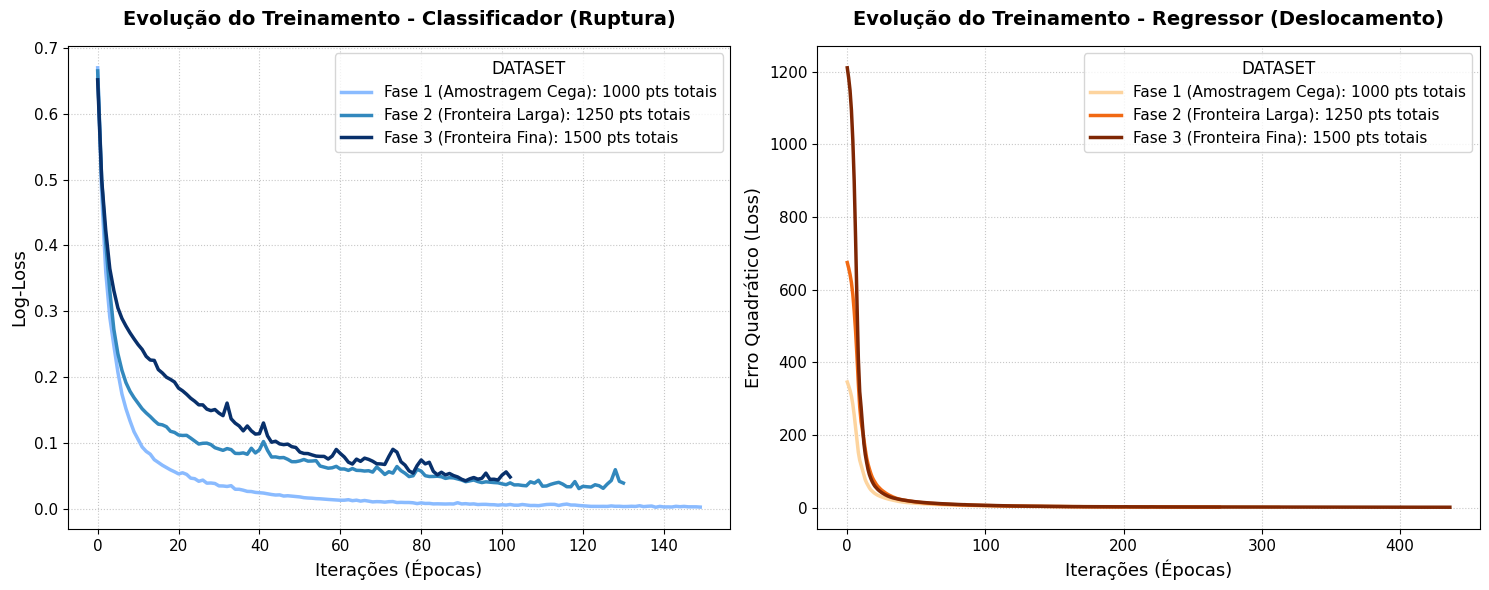

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier, MLPRegressor

# ===================================================================
# 14. TREINAMENTO EVOLUTIVO E COMPARAÇÃO DAS CURVAS DE LOSS
# ===================================================================

print("Iniciando o treinamento das 3 etapas evolutivas. Isso pode levar alguns minutos...")

dir_dados = '/content/Data_Abaqus'

# Definição das configurações de cada etapa de amostragem
etapas = [
    {'nome': 'Etapa 1', 'arquivos': ['Dataset_DoE1000_Final_Extraido.csv'], 'legenda': 'Fase 1 (Amostragem Cega)'},
    {'nome': 'Etapa 2', 'arquivos': ['Dataset_DoE1000_Final_Extraido.csv', 'Dataset_Fronteira_Extraido.csv'], 'legenda': 'Fase 2 (Fronteira Larga)'},
    {'nome': 'Etapa 3', 'arquivos': ['Dataset_DoE1000_Final_Extraido.csv', 'Dataset_Fronteira_Extraido_COMPLETO.csv'], 'legenda': 'Fase 3 (Fronteira Fina)'}
]

# Variáveis para armazenar o histórico de loss e número de amostras
historico_loss_clf = []
historico_loss_reg = []
tamanhos_amostra = []

# Mesmos hiperparâmetros já estabelecidos no notebook (Arquitetura final otimizada do artigo que estou escrevendo)
NEURONIOS = (128, 128, 128)
EPOCAS = 3000
TAXA = 0.001

for etapa in etapas:
    # 1. Carregamento e concatenação dos arquivos da etapa atual
    dfs_temp = []
    for arquivo in etapa['arquivos']:
        try:
            dfs_temp.append(pd.read_csv(f"{dir_dados}/{arquivo}"))
        except FileNotFoundError:
            print(f"[AVISO] {arquivo} não encontrado localmente. Tentando continuar...")

    if not dfs_temp:
        continue

    df_evol = pd.concat(dfs_temp, ignore_index=True)
    df_evol = df_evol.drop_duplicates(subset=['Massa_TNT_kg', 'Espessura_mm', 'Distancia_Z_mm'])

    # Aplicação das mesmas restrições numéricas iniciais
    df_evol = df_evol[
        (df_evol['Distancia_Z_mm'] >= 100.0) &
        (df_evol['Espessura_mm'] <= 8.1)
    ]

    qtd_pontos = len(df_evol)
    tamanhos_amostra.append(qtd_pontos)
    print(f"[{etapa['nome']}] Treinando modelos com {qtd_pontos} pontos de informação...")

    # ---------------------------------------------------------
    # TREINAMENTO DO CLASSIFICADOR
    # ---------------------------------------------------------
    X_clf_evol = df_evol[['Massa_TNT_kg', 'Espessura_mm', 'Distancia_Z_mm']]
    y_clf_evol = df_evol['Status_Ruptura']

    X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clf_evol, y_clf_evol, test_size=0.2, random_state=42)

    scaler_c = StandardScaler()
    X_train_c_scaled = scaler_c.fit_transform(X_train_c)

    clf_evolutivo = MLPClassifier(hidden_layer_sizes=NEURONIOS, max_iter=EPOCAS,
                                  learning_rate_init=TAXA, random_state=42)
    clf_evolutivo.fit(X_train_c_scaled, y_train_c)
    historico_loss_clf.append(clf_evolutivo.loss_curve_)

    # ---------------------------------------------------------
    # TREINAMENTO DO REGRESSOR
    # ---------------------------------------------------------
    df_evol_sup = df_evol[df_evol['Status_Ruptura'] == 0].copy()
    X_reg_evol = df_evol_sup[['Massa_TNT_kg', 'Espessura_mm', 'Distancia_Z_mm']]
    y_reg_evol = df_evol_sup['Desloc_Eixo_Z_m'] * 1000

    X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg_evol, y_reg_evol, test_size=0.2, random_state=42)

    scaler_r = StandardScaler()
    X_train_r_scaled = scaler_r.fit_transform(X_train_r)

    reg_evolutivo = MLPRegressor(hidden_layer_sizes=NEURONIOS, max_iter=EPOCAS,
                                 learning_rate_init=TAXA, random_state=42)
    reg_evolutivo.fit(X_train_r_scaled, y_train_r)
    historico_loss_reg.append(reg_evolutivo.loss_curve_)

print("Treinamentos finalizados. Gerando gráficos comparativos...\n")

# ===================================================================
# PLOTAGEM DO HISTÓRICO DE TREINAMENTO
# ===================================================================

plt.figure(figsize=(15, 6))

# Tons de azul para o classificador e laranja para o regressor (do mais claro para o mais intenso)
cores_clf = ['#8abbff', '#3288bd', '#08306b']
cores_reg = ['#fdd49e', '#f16913', '#7f2704']

# 1. Gráfico Classificador
plt.subplot(1, 2, 1)
for i, curva in enumerate(historico_loss_clf):
    plt.plot(curva, color=cores_clf[i], linewidth=2.5, label=f"{etapas[i]['legenda']}: {tamanhos_amostra[i]} pts totais")
plt.title('Evolução do Treinamento - Classificador (Ruptura)', pad=15, fontsize=14, fontweight='bold')
plt.xlabel('Iterações (Épocas)', fontsize=13)
plt.ylabel('Log-Loss', fontsize=13)
plt.legend(title='DATASET', fontsize=11, title_fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

# 2. Gráfico Regressor
plt.subplot(1, 2, 2)
for i, curva in enumerate(historico_loss_reg):
    # Adicionando uma contagem de íntegros na legenda do regressor para maior precisão
    plt.plot(curva, color=cores_reg[i], linewidth=2.5, label=f"{etapas[i]['legenda']}: {tamanhos_amostra[i]} pts totais")
plt.title('Evolução do Treinamento - Regressor (Deslocamento)', pad=15, fontsize=14, fontweight='bold')
plt.xlabel('Iterações (Épocas)', fontsize=13)
plt.ylabel('Erro Quadrático (Loss)', fontsize=13)
plt.legend(title='DATASET', fontsize=11, title_fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()
